# 📦 Instalação de Dependências

Esta célula instala todas as bibliotecas necessárias para o projeto
Execute apenas uma vez no início da sessão


In [28]:

import sys
import subprocess
import warnings

def instalar_pacotes():
    """Instala pacotes necessários para o projeto"""
    
    print("🚀 Iniciando instalação das dependências...")
    print("="*60)
    
    # Lista de pacotes necessários
    pacotes = [
        'pandas',
        'numpy', 
        'matplotlib',
        'seaborn',
        'plotly',
        'folium',
        'scikit-learn',
        'jupyter',
        'pyarrow'  # Para leitura de arquivos parquet
    ]
    
    pacotes_faltantes = []
    
    # Verificação de pacotes já instalados
    for pacote in pacotes:
        try:
            __import__(pacote)
            print(f"✅ {pacote} - já instalado")
        except ImportError:
            print(f"⬇️ {pacote} - precisa instalar")
            pacotes_faltantes.append(pacote)
    
    if not pacotes_faltantes:
        print("\n🎉 Todos os pacotes já estão instalados!")
        return True
    
    # Instalação dos pacotes faltantes
    print(f"\n📦 Instalando {len(pacotes_faltantes)} pacotes faltantes...")
    
    try:
        # Tenta instalar usando pip (ambiente virtual)
        for pacote in pacotes_faltantes:
            print(f"  🔄 Instalando {pacote}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pacote])
            print(f"  ✅ {pacote} instalado com sucesso!")
        
        print("\n🎉 Instalação concluída com sucesso!")
        return True
        
    except subprocess.CalledProcessError as e:
        print(f"\n❌ Erro na instalação: {e}")
        print("\n💡 Soluções alternativas:")
        print("  1. Ative um ambiente virtual: python -m venv venv && source venv/bin/activate")
        print("  2. Use conda: conda install -c conda-forge pandas numpy matplotlib seaborn plotly folium scikit-learn pyarrow")
        print("  3. Instale manualmente: pip install pandas numpy matplotlib seaborn plotly folium scikit-learn pyarrow")
        return False

# Executa a instalação
if instalar_pacotes():
    print("\n✅ Ambiente pronto para uso!")
else:
    print("\n⚠️ Resolva os problemas de instalação antes de continuar.")
    print("📋 Verifique a documentação do projeto para instruções detalhadas.")

# Limpa warnings para saída mais limpa
warnings.filterwarnings('ignore')
print("\n🔧 Configuração concluída. Prosseja para a próxima célula.")

🚀 Iniciando instalação das dependências...
✅ pandas - já instalado
✅ numpy - já instalado
✅ matplotlib - já instalado
✅ seaborn - já instalado
✅ plotly - já instalado
✅ folium - já instalado
⬇️ scikit-learn - precisa instalar
✅ jupyter - já instalado
✅ pyarrow - já instalado

📦 Instalando 1 pacotes faltantes...
  🔄 Instalando scikit-learn...
  ✅ scikit-learn instalado com sucesso!

🎉 Instalação concluída com sucesso!

✅ Ambiente pronto para uso!

🔧 Configuração concluída. Prosseja para a próxima célula.


## 🔧 Configuração do Ambiente

Nesta seção, vamos configurar as bibliotecas e parâmetros necessários para nossa análise.

In [ ]:
# Importação das bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from datetime import datetime, timedelta
import warnings
import logging
import os

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configuração de logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Configurações do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# 📁 Configuração para salvamento automático de gráficos
GRAFICOS_DIR = "graficos/MVP"
os.makedirs(GRAFICOS_DIR, exist_ok=True)

def salvar_grafico(fig, nome_arquivo, formato='png', dpi=300):
    """
    Função para salvar gráficos automaticamente na pasta graficos/MVP
    
    Parâmetros:
    - fig: objeto do matplotlib ou figura
    - nome_arquivo: nome do arquivo sem extensão
    - formato: formato do arquivo (png, jpg, svg, pdf)
    - dpi: resolução para imagens raster
    """
    try:
        caminho_completo = os.path.join(GRAFICOS_DIR, f"{nome_arquivo}.{formato}")
        
        if hasattr(fig, 'savefig'):  # Matplotlib figure
            fig.savefig(caminho_completo, dpi=dpi, bbox_inches='tight', facecolor='white')
        elif hasattr(fig, 'write_image'):  # Plotly figure
            fig.write_image(caminho_completo, format=formato, width=1200, height=800, scale=2)
        
        print(f"✅ Gráfico salvo: {caminho_completo}")
        logger.info(f"Gráfico salvo com sucesso: {caminho_completo}")
        
    except Exception as e:
        print(f"❌ Erro ao salvar gráfico {nome_arquivo}: {str(e)}")
        logger.error(f"Erro ao salvar gráfico: {str(e)}")

print("✅ Ambiente configurado com sucesso!")
print(f"📦 Bibliotecas carregadas: pandas, numpy, matplotlib, seaborn, plotly, folium, sklearn")
print(f"📁 Gráficos serão salvos em: {GRAFICOS_DIR}")

✅ Ambiente configurado com sucesso!
📦 Bibliotecas carregadas: pandas, numpy, matplotlib, seaborn, plotly, folium, sklearn
📁 Gráficos serão salvos em: graficos/MVP


## 📂 Carregamento e Análise Exploratória dos Dados

Vamos carregar o dataset e realizar uma **análise exploratória inicial** para entender a estrutura e características dos dados.

In [ ]:
# Carregamento do dataset
logger.info("🚀 Iniciando carregamento do dataset...")

try:
    # Carrega o dataset completo
    df = pd.read_parquet('dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.parquet')
    
    # Informações básicas do dataset
    print("\n" + "="*60)
    print("📊 ESTATÍSTICAS GERAIS DO DATASET")
    print("="*60)
    print(f"📏 Total de registros: {df.shape[0]:,}")
    print(f"📋 Total de colunas: {df.shape[1]}")
    print(f"📅 Período: Janeiro a Abril de 2026")
    print(f"🎯 Sensores únicos: {df['NSerie'].nunique()}")
    print(f"📍 Endereços únicos: {df['Endereco'].nunique()}")
    print(f"🚗 Placas únicas: {df['Placa'].nunique():,}")
    
    # Conversão de tipos com formato de data brasileiro confirmado
    logger.info("🔄 Convertendo tipos de dados...")
    
    # Verificação do formato de data antes da conversão
    print("\n🔍 Verificando formato das datas:")
    amostra_datas = df['Datatrafego'].head(5).tolist()
    print(f"  Amostra de datas: {amostra_datas}")
    
    # Conversão DIRETA com formato brasileiro (dd/mm/YYYY)
    print("  📅 Usando formato brasileiro: %d/%m/%Y %H:%M:%S")
    df['Datatrafego'] = pd.to_datetime(df['Datatrafego'], format='%d/%m/%Y %H:%M:%S')
    print("✅ Data convertida com sucesso!")
    
    df['Sentido'] = df['Sentido'].astype('category')
    
    # Extração de features temporais
    df['Data'] = df['Datatrafego'].dt.date
    df['Hora'] = df['Datatrafego'].dt.hour
    df['DiaSemana'] = df['Datatrafego'].dt.day_name()
    df['SemanaAno'] = df['Datatrafego'].dt.isocalendar().week
    df['Mes'] = df['Datatrafego'].dt.month_name()
    
    # Verificação do período de dados
    data_inicio = df['Datatrafego'].min()
    data_fim = df['Datatrafego'].max()
    print(f"\n📅 Período real dos dados:")
    print(f"  Início: {data_inicio.strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"  Fim: {data_fim.strftime('%d/%m/%Y %H:%M:%S')}")
    print(f"  Total de dias: {(data_fim - data_inicio).days + 1}")
    
    # Verificação adicional da conversão
    print(f"\n🔍 Validação da conversão:")
    print(f"  Tipo de dados Datatrafego: {df['Datatrafego'].dtype}")
    print(f"  Data mais antiga: {df['Datatrafego'].min()}")
    print(f"  Data mais recente: {df['Datatrafego'].max()}")
    
    logger.info("✅ Dataset carregado e processado com sucesso!")
    
except Exception as e:
    logger.error(f"❌ Erro no carregamento: {str(e)}")
    print("\n💡 Possíveis soluções:")
    print("  1. Verifique se o arquivo 'dados/DADOS_SOROCABA_JANEIRO_A_ABRIL_2026.parquet' existe")
    print("  2. Verifique o formato das datas no arquivo original")
    print("  3. O formato esperado é: dd/mm/YYYY HH:MM:SS (ex: 13/01/2026 00:04:08)")
    raise

2026-05-04 02:57:44,501 - INFO - 🚀 Iniciando carregamento do dataset...



📊 ESTATÍSTICAS GERAIS DO DATASET
📏 Total de registros: 76,662,221
📋 Total de colunas: 9
📅 Período: Janeiro a Abril de 2026
🎯 Sensores únicos: 61
📍 Endereços únicos: 58


2026-05-04 02:59:43,229 - INFO - 🔄 Convertendo tipos de dados...


🚗 Placas únicas: 3,043,894

🔍 Verificando formato das datas:
  Amostra de datas: ['01/01/2026 00:03:32', '01/01/2026 00:10:29', '01/01/2026 00:11:01', '01/01/2026 00:12:39', '01/01/2026 00:13:33']
  📅 Usando formato brasileiro: %d/%m/%Y %H:%M:%S
✅ Data convertida com sucesso!

📅 Período real dos dados:
  Início: 01/01/2026 00:00:01
  Fim: 23/04/2026 23:59:58
  Total de dias: 113

🔍 Validação da conversão:
  Tipo de dados Datatrafego: datetime64[us]
  Data mais antiga: 2026-01-01 00:00:01


2026-05-04 03:10:42,285 - INFO - ✅ Dataset carregado e processado com sucesso!


  Data mais recente: 2026-04-23 23:59:58


In [31]:
# Análise dos sensores
print("\n" + "="*60)
print("🎯 ANÁLISE DOS SENSORES")
print("="*60)

# Distribuição de registros por sensor
sensor_stats = df.groupby('NSerie').agg({
    'Placa': 'count',
    'Endereco': 'first',
    'Latitude': 'first',
    'Longitude': 'first',
    'Sentido': 'first'
}).rename(columns={'Placa': 'Total_Registros'})

sensor_stats['Media_Diaria'] = sensor_stats['Total_Registros'] / 120  # 120 dias no período
sensor_stats = sensor_stats.sort_values('Total_Registros', ascending=False)

print(f"\n📊 Top 10 sensores por volume de dados:")
display(sensor_stats.head(10))

# Análise dos sentidos
print("\n🧭 Distribuição por sentido:")
sentido_counts = df['Sentido'].value_counts()
sentido_percentages = (sentido_counts / len(df)) * 100

for sentido, count in sentido_counts.items():
    percentage = sentido_percentages[sentido]
    print(f"  {sentido}: {count:,} ({percentage:.1f}%)")


🎯 ANÁLISE DOS SENSORES



📊 Top 10 sensores por volume de dados:


,Total_Registros,Endereco,Latitude,Longitude,Sentido,Media_Diaria
NSerie,,,,,,
1078,4368675,"Av. Dom Aguirre, prox. Rua Com. Helio Monzoni.",-23.49,-47.45,Centro/Bairro,36405.62
1081,3569175,"Av. Dom Aguirre, prox. Rua Com. Helio Monzoni",-23.49,-47.45,Bairro/Centro,29743.12
1077,2945316,"Av. Dom Aguirre, prox. Rua Ana M. Carvalho",-23.48,-47.44,Centro/Bairro,24544.30
1043,2790296,"Av. Dom Aguirre, n? 3303",-23.48,-47.44,Bairro/Centro,23252.47
1135,2652687,"Av. Antonio Carlos Comitre, prox. n? 1315",-23.53,-47.47,Bairro/Centro,22105.72
1806,2380781,Av. Dom Aguirre X Rua Coronel Cavalheiros,-23.50,-47.45,Bairro/Centro,19839.84
1136,2274349,"Av. Eng. Carlos Reinaldo Mendes, Oposto ao n?3041",-23.48,-47.42,Centro/Bairro,18952.91
1021,2268963,"Av. Dr. Armando Pannunzio, n?1800",-23.53,-47.49,Centro/Bairro,18908.03
1134,2266507,"Av. Tadao Yoshida, prox a Ponte Jose N. C. do Val",-23.45,-47.46,Centro/Bairro,18887.56



🧭 Distribuição por sentido:
  Centro/Bairro: 36,489,501 (47.6%)
  Bairro/Centro: 35,541,468 (46.4%)
  Centro-Bairro: 2,269,635 (3.0%)
  Nenhum: 1,218,502 (1.6%)
  Castelinho - Centro: 612,490 (0.8%)
  Centro - Castelinho: 358,782 (0.5%)
  Pq. das Aguas - Castelinho: 171,843 (0.2%)


## 🗺️ Análise Geográfica e Clusterização de Sensores

Vamos analisar a distribuição geográfica dos sensores e realizar **clusterização** para identificar zonas de influência.

In [32]:
# 🔄 Normalização de Sentidos de Tráfego e Tratamento de Coordenadas
logger.info("🔧 Normalizando sentidos de tráfego e tratando coordenadas faltantes...")

def normalizar_sentidos_trafego(df):
    """
    Normalizar os sentidos de tráfego conforme solicitado:
    - Centro-Bairro → Centro/Bairro
    - Castelinho - Centro → Bairro/Centro  
    - Centro - Castelinho → Centro/Bairro
    """
    
    print("🔍 ANÁLISE INICIAL DOS SENTIDOS:")
    sentido_counts = df['Sentido'].value_counts()
    total_registros = len(df)
    
    for sentido, count in sentido_counts.items():
        percentage = (count / total_registros) * 100
        print(f"  {sentido}: {count:,} ({percentage:.1f}%)")
    
    # Mapeamento das normalizações
    mapeamento_sentidos = {
        'Centro-Bairro': 'Centro/Bairro',
        'Castelinho - Centro': 'Bairro/Centro',
        'Centro - Castelinho': 'Centro/Bairro'
    }
    
    print(f"\n🔄 Aplicando normalizações:")
    
    # Aplicação das normalizações
    df_normalizado = df.copy()
    for sentido_antigo, sentido_novo in mapeamento_sentidos.items():
        if sentido_antigo in df_normalizado['Sentido'].values:
            count = df_normalizado[df_normalizado['Sentido'] == sentido_antigo].shape[0]
            df_normalizado.loc[df_normalizado['Sentido'] == sentido_antigo, 'Sentido'] = sentido_novo
            print(f"  ✅ {sentido_antigo} → {sentido_novo} ({count:,} registros)")
    
    # Verificação após normalização
    print(f"\n📊 SENTIDOS APÓS NORMALIZAÇÃO:")
    sentido_counts_norm = df_normalizado['Sentido'].value_counts()
    
    for sentido, count in sentido_counts_norm.items():
        percentage = (count / total_registros) * 100
        print(f"  {sentido}: {count:,} ({percentage:.1f}%)")
    
    return df_normalizado

def aferir_sentido_por_sensores(df):
    """
    Aferir sentido O-D para registros sem sentido definido usando sensores de entrada e saída.
    """
    
    print(f"\n🔍 Aferindo sentido para registros sem sentido definido...")
    
    # Contagem de registros "Nenhum" antes
    registros_nenhum = df[df['Sentido'] == 'Nenhum'].shape[0]
    print(f"  📊 Registros com sentido 'Nenhum': {registros_nenhum:,}")
    
    if registros_nenhum == 0:
        print("  ✅ Não há registros sem sentido definido!")
        return df
    
    # Análise por sensor para determinar padrão predominante
    print(f"  🔍 Analisando padrões por sensor...")
    
    # Para cada sensor, determinar o sentido mais comum
    sentido_predominante_sensor = df[df['Sentido'] != 'Nenhum'].groupby('NSerie')['Sentido'].agg(
        lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'Nenhum'
    ).to_dict()
    
    print(f"  📍 Sentidos predominantes identificados para {len(sentido_predominante_sensor)} sensores")
    
    # Aplicar aferição para registros "Nenhum"
    df_aferido = df.copy()
    mascara_nenhum = df_aferido['Sentido'] == 'Nenhum'
    
    # Contador para acompanhamento
    registros_aferidos = 0
    
    for nserie in df_aferido.loc[mascara_nenhum, 'NSerie'].unique():
        if nserie in sentido_predominante_sensor:
            sentido_inferido = sentido_predominante_sensor[nserie]
            if sentido_inferido != 'Nenhum':
                mascara_sensor = (df_aferido['NSerie'] == nserie) & (df_aferido['Sentido'] == 'Nenhum')
                count = mascara_sensor.sum()
                df_aferido.loc[mascara_sensor, 'Sentido'] = sentido_inferido
                registros_aferidos += count
                print(f"    🔄 Sensor {nserie}: {sentido_inferido} ({count:,} registros)")
    
    print(f"\n✅ Aferição concluída:")
    print(f"  📊 Registros aferidos: {registros_aferidos:,}")
    print(f"  📊 Registros restantes 'Nenhum': {df_aferido[df_aferido['Sentido'] == 'Nenhum'].shape[0]:,}")
    
    return df_aferido

def preencher_coordenadas_por_sensor(df):
    """
    Preencher coordenadas faltantes (Latitude/Longitude) usando o código do sensor como referência.
    """
    
    print(f"\n📊 ANÁLISE INICIAL DE COORDENADAS FALTANTES:")
    
    # Verificação inicial de valores nulos
    lat_nulas = df['Latitude'].isnull().sum()
    lon_nulas = df['Longitude'].isnull().sum()
    total_registros = len(df)
    
    print(f"  • Total de registros: {total_registros:,}")
    print(f"  • Latitude nulas: {lat_nulas:,} ({lat_nulas/total_registros*100:.2f}%)")
    print(f"  • Longitude nulas: {lon_nulas:,} ({lon_nulas/total_registros*100:.2f}%)")
    
    if lat_nulas == 0 and lon_nulas == 0:
        print("✅ Não há coordenadas faltantes!")
        return df
    
    # Criação de dicionário de coordenadas por sensor
    print(f"\n🔍 Construindo dicionário de coordenadas por sensor...")
    
    coordenadas_sensor = df.groupby('NSerie').agg({
        'Latitude': 'first',
        'Longitude': 'first'
    }).dropna()
    
    print(f"  • Sensores com coordenadas conhecidas: {len(coordenadas_sensor)}")
    print(f"  • Sensores sem coordenadas: {df['NSerie'].nunique() - len(coordenadas_sensor)}")
    
    # Preenchimento das coordenadas faltantes
    print(f"\n🔄 Preenchendo coordenadas faltantes...")
    
    # Contador para acompanhamento
    preenchidas_lat = 0
    preenchidas_lon = 0
    
    # Para cada sensor com coordenadas conhecidas
    for nserie, coords in coordenadas_sensor.iterrows():
        lat = coords['Latitude']
        lon = coords['Longitude']
        
        # Encontra registros do mesmo sensor com coordenadas nulas
        mask = (df['NSerie'] == nserie) & (df['Latitude'].isnull())
        count_lat = mask.sum()
        if count_lat > 0:
            df.loc[mask, 'Latitude'] = lat
            preenchidas_lat += count_lat
        
        mask = (df['NSerie'] == nserie) & (df['Longitude'].isnull())
        count_lon = mask.sum()
        if count_lon > 0:
            df.loc[mask, 'Longitude'] = lon
            preenchidas_lon += count_lon
    
    # Verificação final
    print(f"\n✅ Preenchimento concluído:")
    print(f"  • Latitude preenchidas: {preenchidas_lat:,}")
    print(f"  • Longitude preenchidas: {preenchidas_lon:,}")
    
    return df

# Aplicação sequencial das normalizações
print("🚀 INICIANDO PROCESSO DE NORMALIZAÇÃO E TRATAMENTO")
print("="*60)

# 1. Normalização dos sentidos de tráfego
df_normalizado = normalizar_sentidos_trafego(df.copy())

# 2. Aferição de sentidos para registros "Nenhum"
df_aferido = aferir_sentido_por_sensores(df_normalizado)

# 3. Preenchimento de coordenadas faltantes
df_tratado = preencher_coordenadas_por_sensor(df_aferido)

# Atualização do dataframe principal
df = df_tratado

print(f"\n" + "="*60)
print("📈 RESUMO DAS TRANSFORMAÇÕES")
print("="*60)

# Estatísticas finais
print(f"📊 Distribuição final de sentidos:")
sentido_counts_final = df['Sentido'].value_counts()
total_final = len(df)

for sentido, count in sentido_counts_final.items():
    percentage = (count / total_final) * 100
    print(f"  {sentido}: {count:,} ({percentage:.1f}%)")

# Verificação de coordenadas
sensores_com_coords = df.dropna(subset=['Latitude', 'Longitude'])['NSerie'].nunique()
total_sensores = df['NSerie'].nunique()

print(f"\n📍 Sensores com coordenadas: {sensores_com_coords}/{total_sensores} ({sensores_com_coords/total_sensores*100:.1f}%)")
print(f"📏 Registros com coordenadas completas: {df.dropna(subset=['Latitude', 'Longitude']).shape[0]:,}")

print(f"\n✅ Dados normalizados e tratados com sucesso!")
print(f"🎯 Agora podemos prosseguir com a análise de clusterização aprimorada.")

2026-05-04 03:11:44,353 - INFO - 🔧 Normalizando sentidos de tráfego e tratando coordenadas faltantes...


🚀 INICIANDO PROCESSO DE NORMALIZAÇÃO E TRATAMENTO
🔍 ANÁLISE INICIAL DOS SENTIDOS:
  Centro/Bairro: 36,489,501 (47.6%)
  Bairro/Centro: 35,541,468 (46.4%)
  Centro-Bairro: 2,269,635 (3.0%)
  Nenhum: 1,218,502 (1.6%)
  Castelinho - Centro: 612,490 (0.8%)
  Centro - Castelinho: 358,782 (0.5%)
  Pq. das Aguas - Castelinho: 171,843 (0.2%)

🔄 Aplicando normalizações:
  ✅ Centro-Bairro → Centro/Bairro (2,269,635 registros)
  ✅ Castelinho - Centro → Bairro/Centro (612,490 registros)
  ✅ Centro - Castelinho → Centro/Bairro (358,782 registros)

📊 SENTIDOS APÓS NORMALIZAÇÃO:
  Centro/Bairro: 39,117,918 (51.0%)
  Bairro/Centro: 36,153,958 (47.2%)
  Nenhum: 1,218,502 (1.6%)
  Pq. das Aguas - Castelinho: 171,843 (0.2%)
  Castelinho - Centro: 0 (0.0%)
  Centro - Castelinho: 0 (0.0%)
  Centro-Bairro: 0 (0.0%)

🔍 Aferindo sentido para registros sem sentido definido...
  📊 Registros com sentido 'Nenhum': 1,218,502
  🔍 Analisando padrões por sensor...
  📍 Sentidos predominantes identificados para 59 sens

2026-05-04 03:32:47,007 - INFO - 🎯 Iniciando clusterização aprimorada com dados normalizados...



📊 ANÁLISE DE SENTIDOS APÓS NORMALIZAÇÃO


📍 Centro/Bairro: 39,117,918 (51.0%)
📍 Bairro/Centro: 36,153,958 (47.2%)
📍 Nenhum: 1,218,502 (1.6%)
📍 Pq. das Aguas - Castelinho: 171,843 (0.2%)
📍 Castelinho - Centro: 0 (0.0%)
📍 Centro - Castelinho: 0 (0.0%)
📍 Centro-Bairro: 0 (0.0%)

📍 Sensores únicos para clustering: 59
📍 Distribuição de sentidos por sensor:
  Centro/Bairro: 30 sensores (50.8%)
  Bairro/Centro: 25 sensores (42.4%)
  Nenhum: 2 sensores (3.4%)
  Pq. das Aguas - Castelinho: 2 sensores (3.4%)
  Castelinho - Centro: 0 sensores (0.0%)
  Centro - Castelinho: 0 sensores (0.0%)
  Centro-Bairro: 0 sensores (0.0%)


2026-05-04 03:33:59,695 - INFO - Gráfico salvo com sucesso: graficos/MVP/analise_clusters_aprimorada_metodo_cotovelo.png


✅ Gráfico salvo: graficos/MVP/analise_clusters_aprimorada_metodo_cotovelo.png


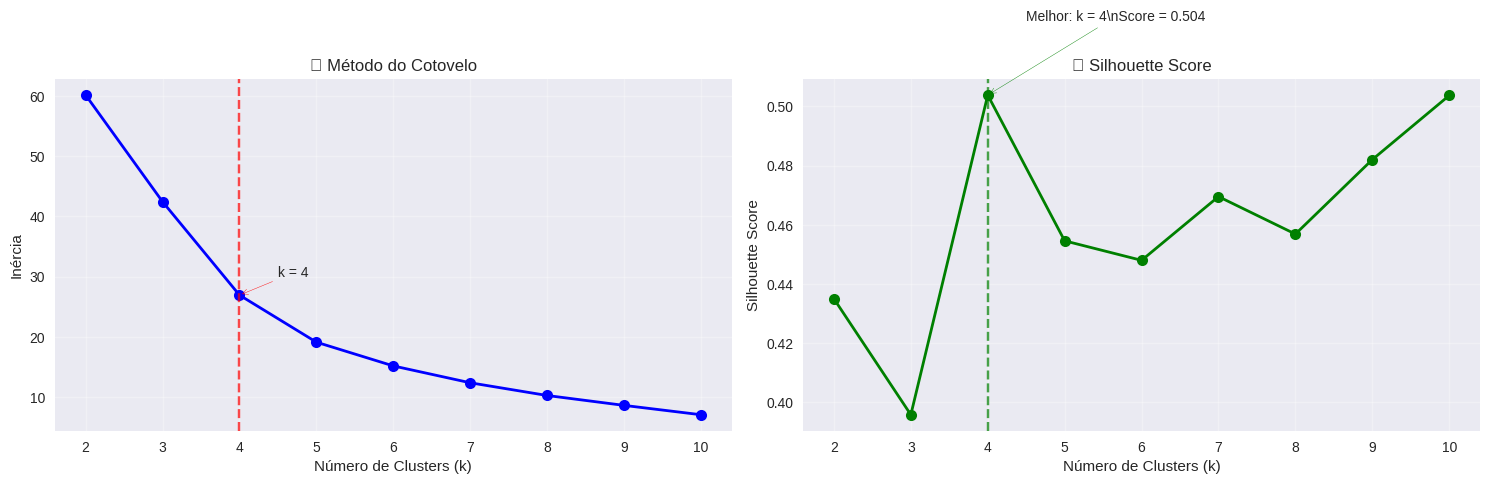

🎯 Número ótimo de clusters escolhido: 4
📊 Silhouette score para k=4: 0.504


In [33]:
# 🎯 Clusterização Aprimorada com Dados Normalizados
logger.info("🎯 Iniciando clusterização aprimorada com dados normalizados...")

# Análise dos sentidos normalizados
print("\n" + "="*60)
print("📊 ANÁLISE DE SENTIDOS APÓS NORMALIZAÇÃO")
print("="*60)

sentido_counts = df['Sentido'].value_counts()
total_registros = len(df)

for sentido, count in sentido_counts.items():
    percentage = (count / total_registros) * 100
    print(f"📍 {sentido}: {count:,} ({percentage:.1f}%)")

# Preparação dos dados para clustering com informações de sentido
sensores_unicos = df.groupby('NSerie').agg({
    'Latitude': 'first',
    'Longitude': 'first',
    'Endereco': 'first',
    'Sentido': lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'Nenhum'
}).dropna(subset=['Latitude', 'Longitude'])

print(f"\n📍 Sensores únicos para clustering: {len(sensores_unicos)}")
print(f"📍 Distribuição de sentidos por sensor:")

sentido_por_sensor = sensores_unicos['Sentido'].value_counts()
for sentido, count in sentido_por_sensor.items():
    percentage = (count / len(sensores_unicos)) * 100
    print(f"  {sentido}: {count} sensores ({percentage:.1f}%)")

# Features para clustering (coordenadas geográficas)
X = sensores_unicos[['Latitude', 'Longitude']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determinação do número ótimo de clusters (método do cotovelo e silhouette)
inertias = []
silhouette_scores = []
k_range = range(2, min(11, len(sensores_unicos)//2))  # Limitar k pelo número de sensores

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Visualização do método do cotovelo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico do cotovelo
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('📊 Método do Cotovelo')
ax1.grid(True, alpha=0.3)

# Marcação do ponto de cotovelo (aproximado)
if len(k_range) > 2:
    # Cálculo simples do ponto de cotovelo
    deltas = np.diff(inertias)
    second_deltas = np.diff(deltas)
    if len(second_deltas) > 0:
        cotovelo_idx = np.argmax(second_deltas) + 1
        if cotovelo_idx < len(k_range):
            ax1.axvline(x=k_range[cotovelo_idx], color='red', linestyle='--', alpha=0.7)
            ax1.annotate(f'k = {k_range[cotovelo_idx]}', 
                        xy=(k_range[cotovelo_idx], inertias[cotovelo_idx]),
                        xytext=(k_range[cotovelo_idx]+0.5, inertias[cotovelo_idx]+max(inertias)*0.05),
                        arrowprops=dict(arrowstyle='->', color='red'))

# Gráfico do silhouette score
ax2.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('📈 Silhouette Score')
ax2.grid(True, alpha=0.3)

# Marcação do melhor silhouette
if len(silhouette_scores) > 0:
    best_k_idx = np.argmax(silhouette_scores)
    best_k = k_range[best_k_idx]
    best_score = silhouette_scores[best_k_idx]
    ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7)
    ax2.annotate(f'Melhor: k = {best_k}\\nScore = {best_score:.3f}', 
                xy=(best_k, best_score),
                xytext=(best_k+0.5, best_score+max(silhouette_scores)*0.05),
                arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()

# 💾 Salvando o gráfico de análise de clusters aprimorado
salvar_grafico(fig, 'analise_clusters_aprimorada_metodo_cotovelo', 'png', 300)

plt.show()

# Escolha automática do número ótimo de clusters
if len(silhouette_scores) > 0:
    k_optimo = k_range[np.argmax(silhouette_scores)]
else:
    k_optimo = min(4, len(sensores_unicos)//2)  # Padrão seguro

print(f"🎯 Número ótimo de clusters escolhido: {k_optimo}")
print(f"📊 Silhouette score para k={k_optimo}: {silhouette_scores[k_range.index(k_optimo)]:.3f}")

2026-05-04 03:34:00,393 - INFO - 🔄 Aplicando K-means com 4 clusters e análise de sentidos...



🎯 ANÁLISE DETALHADA DOS CLUSTERS DE SENSORES

📍 Cluster 0:
  📊 Total de sensores: 29
  📍 Centroide: (0.117533, 0.588494)
  🧭 Distribuição de sentidos:
    Bairro/Centro: 14 sensores (48.3%)
    Centro/Bairro: 13 sensores (44.8%)
    Pq. das Aguas - Castelinho: 2 sensores (6.9%)
    Castelinho - Centro: 0 sensores (0.0%)
    Centro - Castelinho: 0 sensores (0.0%)
    Centro-Bairro: 0 sensores (0.0%)
    Nenhum: 0 sensores (0.0%)
  🏢 Endereços representativos:
    • Av. Jose Joaquim de Lacerda, oposto ao n?422
    • Rua Paes de Linhares, n?918
    • Av. Com. Camillo Julio, n?2511
    ... e mais 26 endereços

📍 Cluster 1:
  📊 Total de sensores: 19
  📍 Centroide: (-1.047525, -0.970451)
  🧭 Distribuição de sentidos:
    Centro/Bairro: 10 sensores (52.6%)
    Bairro/Centro: 9 sensores (47.4%)
    Castelinho - Centro: 0 sensores (0.0%)
    Centro - Castelinho: 0 sensores (0.0%)
    Centro-Bairro: 0 sensores (0.0%)
    Nenhum: 0 sensores (0.0%)
    Pq. das Aguas - Castelinho: 0 sensores (0.0%

2026-05-04 03:34:08,192 - INFO - Gráfico salvo com sucesso: graficos/MVP/distribuicao_sentidos_por_cluster.png


✅ Gráfico salvo: graficos/MVP/distribuicao_sentidos_por_cluster.png


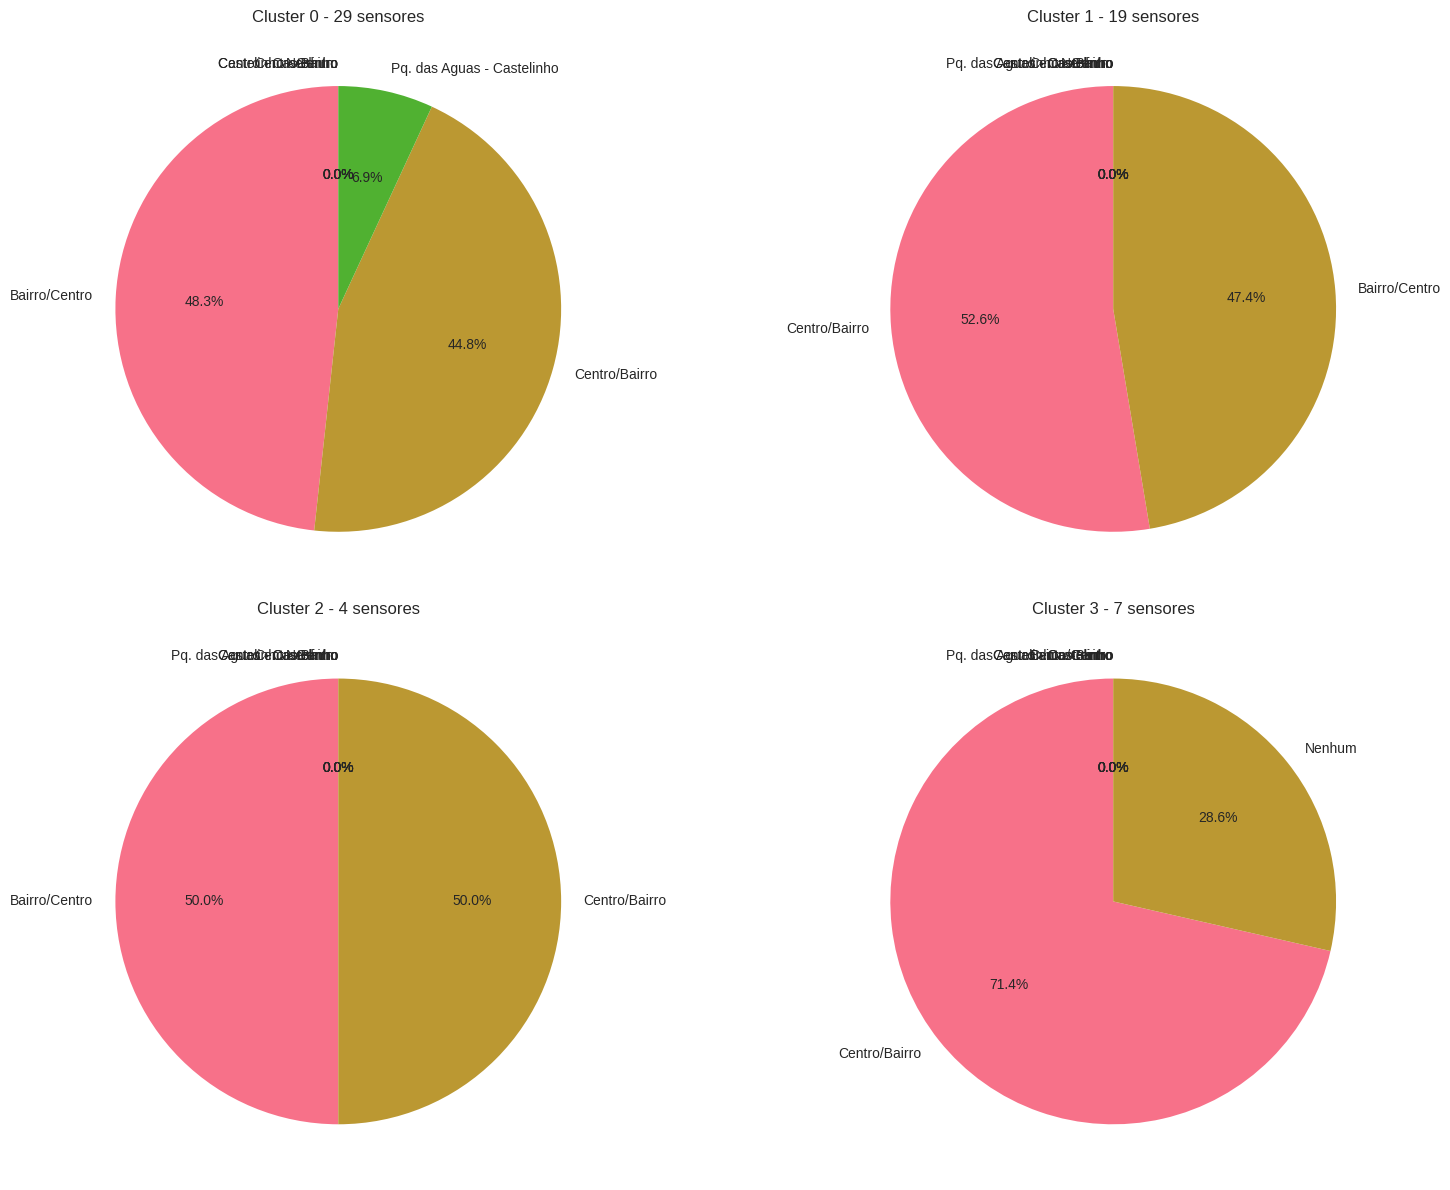


🗺️ Mapa aprimorado com clusters e sentidos criado!
📊 Legenda:
  • Cor da borda: Cluster
  • Cor de preenchimento: Sentido predominante
  • Azul: Centro/Bairro | Vermelho: Bairro/Centro | Cinza: Nenhum


In [34]:
# 🔄 Aplicação do Clustering com Análise de Sentidos
logger.info(f"🔄 Aplicando K-means com {k_optimo} clusters e análise de sentidos...")

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Adição dos labels ao dataframe
sensores_unicos['Cluster'] = cluster_labels

# Resetar o índice para converter NSerie de volta para coluna
sensores_unicos = sensores_unicos.reset_index()

# Análise detalhada dos clusters com sentidos
print("\n" + "="*60)
print("🎯 ANÁLISE DETALHADA DOS CLUSTERS DE SENSORES")
print("="*60)

for cluster in range(k_optimo):
    sensores_cluster = sensores_unicos[sensores_unicos['Cluster'] == cluster]
    sentidos_cluster = sensores_cluster['Sentido'].value_counts()
    
    print(f"\n📍 Cluster {cluster}:")
    print(f"  📊 Total de sensores: {len(sensores_cluster)}")
    print(f"  📍 Centroide: ({kmeans_final.cluster_centers_[cluster][0]:.6f}, {kmeans_final.cluster_centers_[cluster][1]:.6f})")
    print(f"  🧭 Distribuição de sentidos:")
    
    for sentido, count in sentidos_cluster.items():
        percentage = (count / len(sensores_cluster)) * 100
        print(f"    {sentido}: {count} sensores ({percentage:.1f}%)")
    
    print(f"  🏢 Endereços representativos:")
    endereços = sensores_cluster['Endereco'].values
    for i, endereco in enumerate(endereços[:3]):  # Mostra até 3 endereços
        print(f"    • {endereco}")
    if len(endereços) > 3:
        print(f"    ... e mais {len(endereços) - 3} endereços")

# Análise do balanceamento entre sentidos nos clusters
print(f"\n" + "="*60)
print("📊 BALANCEAMENTO DE SENTIDOS NOS CLUSTERS")
print("="*60)

# Matriz de sentidos por cluster
matriz_sentidos_cluster = pd.crosstab(sensores_unicos['Cluster'], sensores_unicos['Sentido'])

# Normalização para mostrar percentuais
matriz_percentual = (matriz_sentidos_cluster.div(matriz_sentidos_cluster.sum(axis=1), axis=0) * 100).round(1)

print("📈 Percentual de sensores por sentido em cada cluster:")
print(matriz_percentual)

# Visualização da distribuição de sentidos por cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for cluster in range(min(k_optimo, 4)):  # Limitar a 4 clusters para visualização
    dados_cluster = sensores_unicos[sensores_unicos['Cluster'] == cluster]
    sentidos_counts = dados_cluster['Sentido'].value_counts()
    
    # Gráfico de pizza para cada cluster
    axes[cluster].pie(sentidos_counts.values, labels=sentidos_counts.index, autopct='%1.1f%%', startangle=90)
    axes[cluster].set_title(f'Cluster {cluster} - {len(dados_cluster)} sensores')

# Ajustar layout
plt.tight_layout()

# 💾 Salvando o gráfico de distribuição de sentidos por cluster
salvar_grafico(fig, 'distribuicao_sentidos_por_cluster', 'png', 300)

plt.show()

# Visualização dos clusters no mapa com cores por sentido predominante
mapa_clusters_aprimorado = folium.Map(
    location=[sensores_unicos['Latitude'].mean(), sensores_unicos['Longitude'].mean()],
    zoom_start=12,
    tiles='OpenStreetMap'
)

# Cores para clusters e sentidos
cores_clusters = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige', 'darkblue', 'darkgreen']
cores_sentidos = {
    'Centro/Bairro': 'blue',
    'Bairro/Centro': 'red', 
    'Nenhum': 'gray',
    'Pq. das Aguas - Castelinho': 'orange'
}

# CORREÇÃO: Agora NSerie é uma coluna após reset_index()
for _, sensor in sensores_unicos.iterrows():
    cor_cluster = cores_clusters[sensor['Cluster'] % len(cores_clusters)]
    cor_sentido = cores_sentidos.get(sensor['Sentido'], 'black')
    
    # Ícone baseado no sentido predominante
    icon_circle = folium.CircleMarker(
        location=[sensor['Latitude'], sensor['Longitude']],
        radius=12,
        popup=f"""<b>Sensor {sensor['NSerie']}</b><br>
                  <b>Cluster:</b> {sensor['Cluster']}<br>
                  <b>Sentido:</b> {sensor['Sentido']}<br>
                  <b>Endereço:</b> {sensor['Endereco']}""",
        color=cor_cluster,
        fill=True,
        fillColor=cor_sentido,
        fillOpacity=0.7,
        weight=2
    )
    icon_circle.add_to(mapa_clusters_aprimorado)

print(f"\n🗺️ Mapa aprimorado com clusters e sentidos criado!")
print(f"📊 Legenda:")
print(f"  • Cor da borda: Cluster")
print(f"  • Cor de preenchimento: Sentido predominante")
print(f"  • Azul: Centro/Bairro | Vermelho: Bairro/Centro | Cinza: Nenhum")

# Adicionar legenda ao mapa
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 120px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white;
     ">&nbsp; <b>Legenda</b> <br>
     &nbsp; <i class="fa fa-circle" style="color:blue"></i> Centro/Bairro <br>
     &nbsp; <i class="fa fa-circle" style="color:red"></i> Bairro/Centro <br>
     &nbsp; <i class="fa fa-circle" style="color:gray"></i> Nenhum <br>
     &nbsp; <i class="fa fa-circle" style="color:orange"></i> Outros <br>
     &nbsp; <small>Borda = Cluster</small>
</div>
'''
mapa_clusters_aprimorado.get_root().html.add_child(folium.Element(legend_html))

display(mapa_clusters_aprimorado)

2026-05-04 03:34:09,128 - INFO - 🎯 Analisando padrões de tráfego por cluster...



📊 PADRÕES DE TRÁFEGO POR CLUSTER E HORA

📍 Cluster 0.0:
  📊 Total de registros: 41,659,195
  🚗 Veículos únicos: 1,966,178
  📅 Dias cobertos: 113
  ⏰ Horas de pico:
    17:00 - 3,146,909 veículos
    18:00 - 2,972,995 veículos
    16:00 - 2,751,019 veículos
  🧭 Sentido predominante: Centro/Bairro (50.7%)

📍 Cluster 1.0:
  📊 Total de registros: 21,698,858
  🚗 Veículos únicos: 1,554,097
  📅 Dias cobertos: 113
  ⏰ Horas de pico:
    17:00 - 1,556,679 veículos
    18:00 - 1,469,720 veículos
    12:00 - 1,427,000 veículos
  🧭 Sentido predominante: Bairro/Centro (57.3%)

📍 Cluster 2.0:
  📊 Total de registros: 3,150,390
  🚗 Veículos únicos: 340,402
  📅 Dias cobertos: 113
  ⏰ Horas de pico:
    17:00 - 290,029 veículos
    07:00 - 241,286 veículos
    06:00 - 235,179 veículos
  🧭 Sentido predominante: Centro/Bairro (53.1%)

📍 Cluster 3.0:
  📊 Total de registros: 7,095,363
  🚗 Veículos únicos: 486,668
  📅 Dias cobertos: 113
  ⏰ Horas de pico:
    18:00 - 518,966 veículos
    17:00 - 513,287 veí

2026-05-04 03:50:25,931 - INFO - Gráfico salvo com sucesso: graficos/MVP/padroes_temporais_por_cluster.png


✅ Gráfico salvo: graficos/MVP/padroes_temporais_por_cluster.png


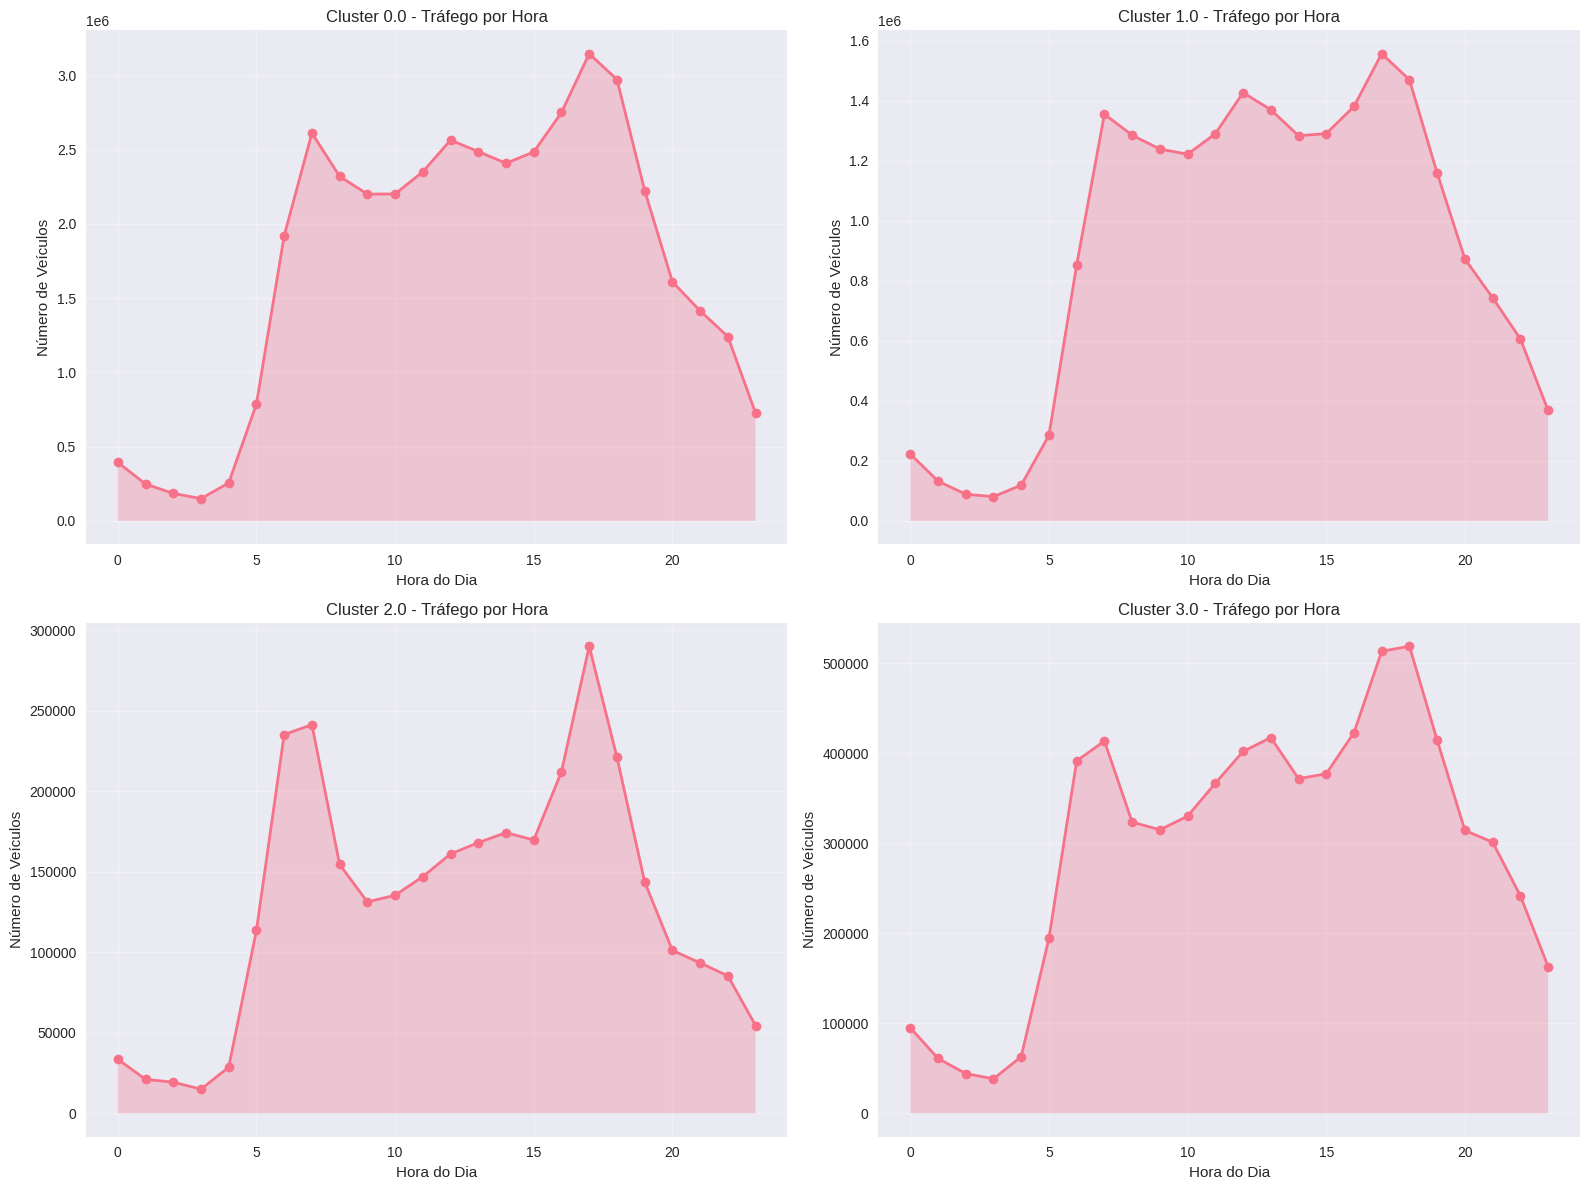


📈 ANÁLISE DE CORRELAÇÃO ENTRE CLUSTERS
📊 Matriz de correlação entre clusters:
Cluster  0.00  1.00  2.00  3.00
Cluster                        
0.00     1.00  0.99  0.92  0.97
1.00     0.99  1.00  0.87  0.95
2.00     0.92  0.87  1.00  0.93
3.00     0.97  0.95  0.93  1.00


2026-05-04 03:50:42,659 - INFO - Gráfico salvo com sucesso: graficos/MVP/correlacao_clusters.png


✅ Gráfico salvo: graficos/MVP/correlacao_clusters.png


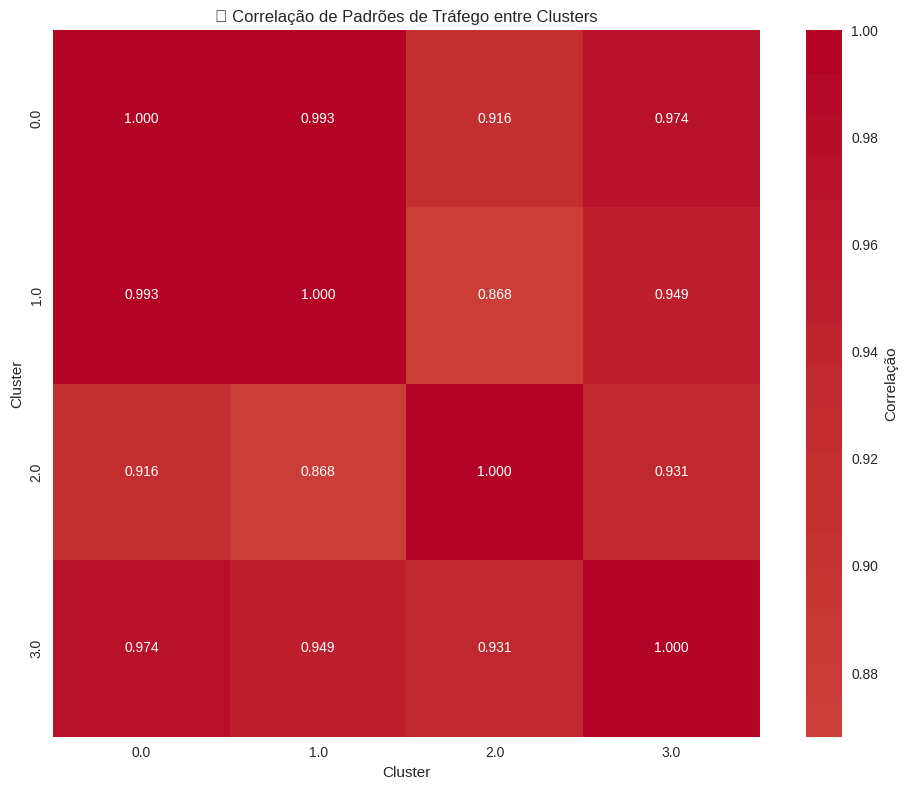


✅ Análise de padrões de tráfego por cluster concluída!
🎯 Insights gerados para 4 clusters


In [35]:
# 📊 Análise de Padrões de Tráfego por Cluster
logger.info("🎯 Analisando padrões de tráfego por cluster...")

# CORREÇÃO: Resetar o índice para transformar NSerie em coluna antes do merge
sensores_unicos_com_nserie = sensores_unicos.reset_index()

# Merge dos dados com informações de cluster usando NSerie como coluna
df_com_cluster = df.merge(sensores_unicos_com_nserie[['NSerie', 'Cluster']], on='NSerie', how='left')

# Análise de tráfego por cluster e hora
trafego_cluster_hora = df_com_cluster.groupby(['Cluster', 'Hora']).agg({
    'Placa': 'count',
    'Sentido': lambda x: x.value_counts().index[0] if len(x.value_counts()) > 0 else 'Nenhum'
}).rename(columns={'Placa': 'Total_Veiculos'})

print("\n" + "="*60)
print("📊 PADRÕES DE TRÁFEGO POR CLUSTER E HORA")
print("="*60)

# Análise por cluster
for cluster in sorted(df_com_cluster['Cluster'].dropna().unique()):
    dados_cluster = df_com_cluster[df_com_cluster['Cluster'] == cluster]
    
    print(f"\n📍 Cluster {cluster}:")
    print(f"  📊 Total de registros: {len(dados_cluster):,}")
    print(f"  🚗 Veículos únicos: {dados_cluster['Placa'].nunique():,}")
    print(f"  📅 Dias cobertos: {dados_cluster['Data'].nunique()}")
    
    # Horas de pico
    horas_pico = dados_cluster.groupby('Hora')['Placa'].count().sort_values(ascending=False).head(3)
    print(f"  ⏰ Horas de pico:")
    for hora, count in horas_pico.items():
        print(f"    {hora:02d}:00 - {count:,} veículos")
    
    # Sentido predominante
    sentido_predominante = dados_cluster['Sentido'].value_counts().index[0]
    sentido_percentual = (dados_cluster['Sentido'].value_counts().iloc[0] / len(dados_cluster)) * 100
    print(f"  🧭 Sentido predominante: {sentido_predominante} ({sentido_percentual:.1f}%)")

# Visualização dos padrões temporais por cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, cluster in enumerate(sorted(df_com_cluster['Cluster'].dropna().unique())):
    if i >= 4:  # Limitar a 4 clusters para visualização
        break
        
    dados_cluster = df_com_cluster[df_com_cluster['Cluster'] == cluster]
    trafego_por_hora = dados_cluster.groupby('Hora')['Placa'].count()
    
    axes[i].plot(trafego_por_hora.index, trafego_por_hora.values, marker='o', linewidth=2)
    axes[i].set_title(f'Cluster {cluster} - Tráfego por Hora')
    axes[i].set_xlabel('Hora do Dia')
    axes[i].set_ylabel('Número de Veículos')
    axes[i].grid(True, alpha=0.3)
    axes[i].fill_between(trafego_por_hora.index, trafego_por_hora.values, alpha=0.3)

plt.tight_layout()

# 💾 Salvando o gráfico de padrões temporais por cluster
salvar_grafico(fig, 'padroes_temporais_por_cluster', 'png', 300)

plt.show()

# Análise de correlação entre clusters
print(f"\n" + "="*60)
print("📈 ANÁLISE DE CORRELAÇÃO ENTRE CLUSTERS")
print("="*60)

# Criar matriz de correlação entre clusters baseada no padrão horário
matriz_trafego = df_com_cluster.groupby(['Cluster', 'Hora'])['Placa'].count().unstack(fill_value=0)
correlacao_clusters = matriz_trafego.T.corr()

print("📊 Matriz de correlação entre clusters:")
print(correlacao_clusters.round(3))

# Visualização da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlacao_clusters, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'label': 'Correlação'})
plt.title('📈 Correlação de Padrões de Tráfego entre Clusters')
plt.tight_layout()

# 💾 Salvando o gráfico de correlação
salvar_grafico(plt.gcf(), 'correlacao_clusters', 'png', 300)

plt.show()

print(f"\n✅ Análise de padrões de tráfego por cluster concluída!")
print(f"🎯 Insights gerados para {len(df_com_cluster['Cluster'].dropna().unique())} clusters")

## ⏰ Análise Temporal de Padrões de Tráfego

Vamos analisar os **padrões temporais** do tráfego para identificar horários de pico e variações conforme dias da semana.

2026-05-04 03:50:48,300 - INFO - ⏰ Iniciando análise temporal de padrões de tráfego...
2026-05-04 03:51:20,321 - INFO - Gráfico salvo com sucesso: graficos/MVP/analise_temporal_padroes_trafego.png


✅ Gráfico salvo: graficos/MVP/analise_temporal_padroes_trafego.png


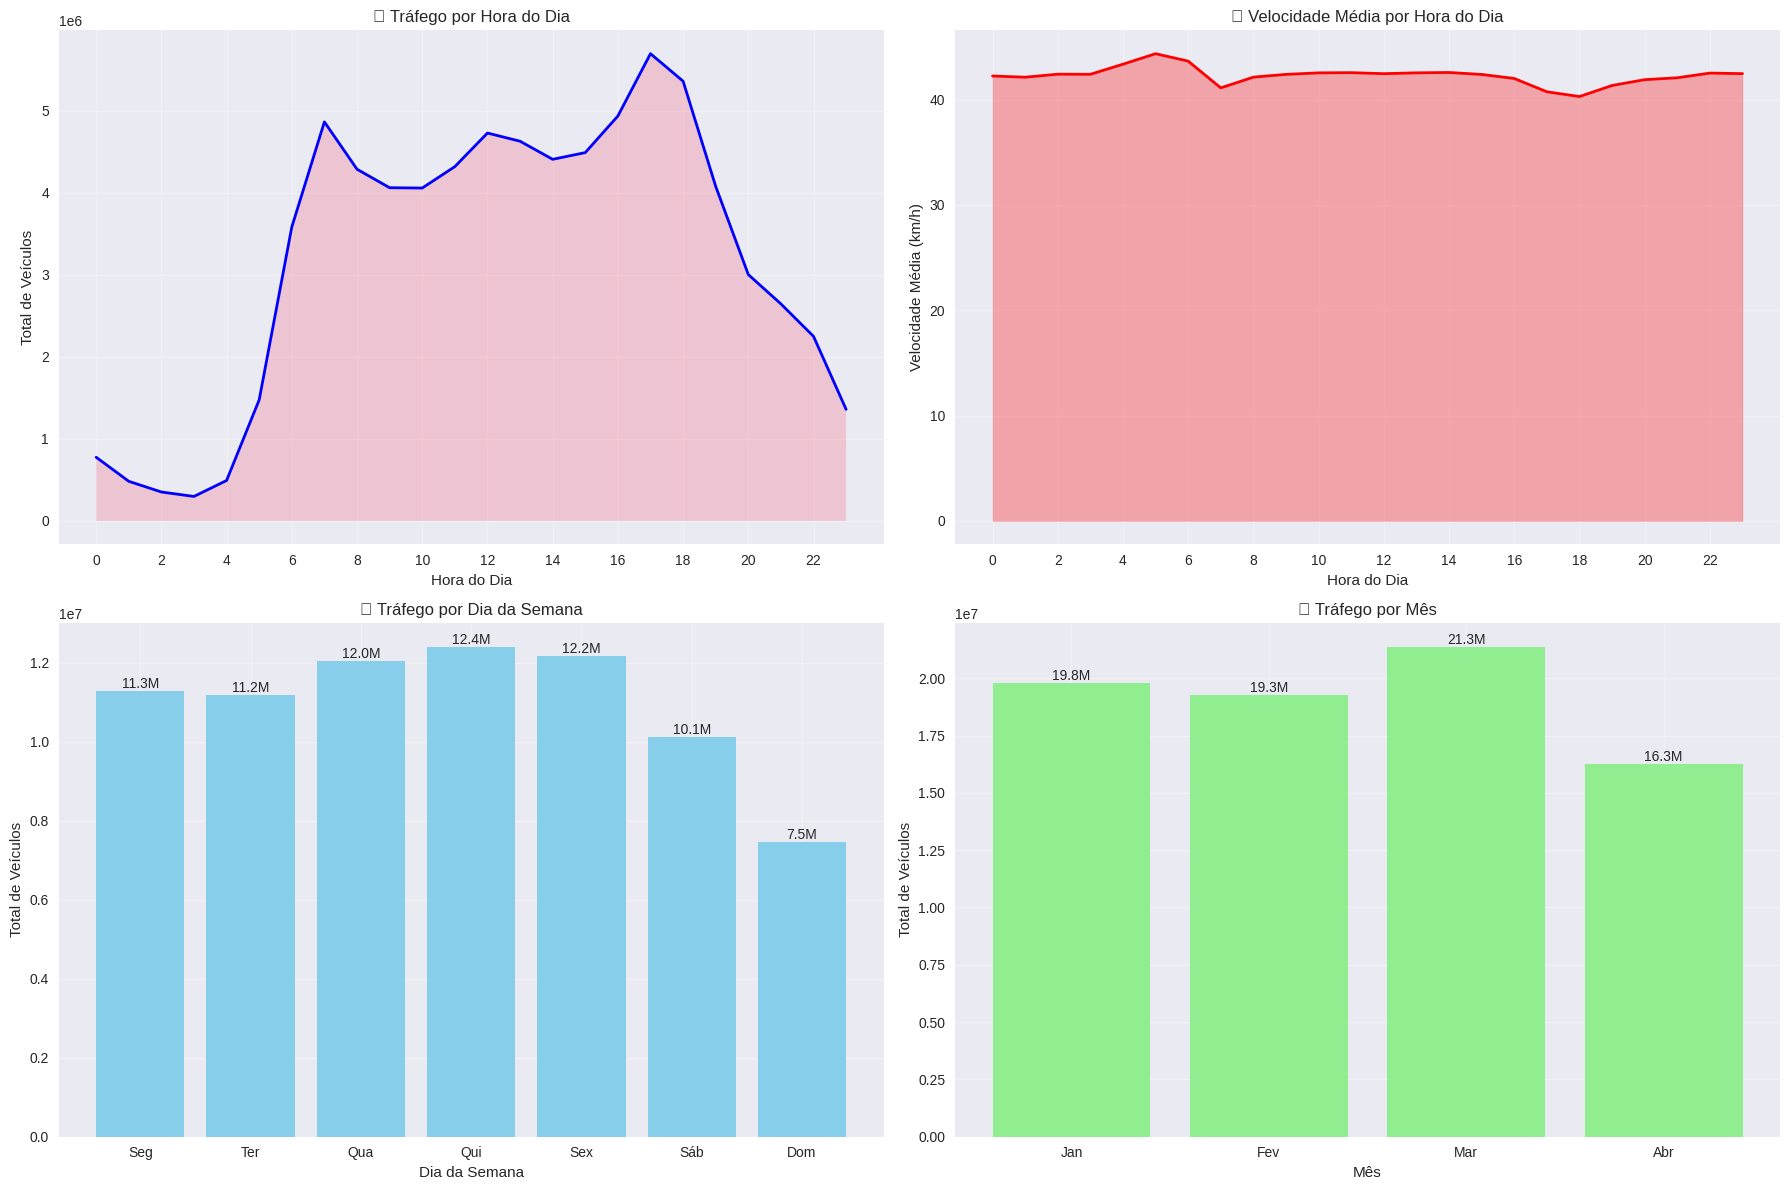


🚦 Horários de pico identificados:
  17:00 - 5,698,252.0 veículos (40.7 km/h média)
  18:00 - 5,363,014.0 veículos (40.3 km/h média)
  16:00 - 4,937,835.0 veículos (42.0 km/h média)


In [36]:
# Análise temporal do tráfego
logger.info("⏰ Iniciando análise temporal de padrões de tráfego...")

# Análise por hora do dia
trafego_por_hora = df.groupby('Hora').agg({
    'Placa': 'count',
    'Velocidade 1': 'mean',
    'Velocidade Regul': 'first'
}).rename(columns={'Placa': 'Total_Veiculos', 'Velocidade 1': 'Velocidade_Media'})

# Análise por dia da semana
trafego_por_dia = df.groupby('DiaSemana').agg({
    'Placa': 'count',
    'Velocidade 1': 'mean'
}).rename(columns={'Placa': 'Total_Veiculos', 'Velocidade 1': 'Velocidade_Media'})

# Análise por mês
trafego_por_mes = df.groupby('Mes').agg({
    'Placa': 'count',
    'Velocidade 1': 'mean'
}).rename(columns={'Placa': 'Total_Veiculos', 'Velocidade 1': 'Velocidade_Media'})

# Visualização dos padrões temporais
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Gráfico 1: Tráfego por hora do dia
axes[0, 0].plot(trafego_por_hora.index, trafego_por_hora['Total_Veiculos'], 'b-', linewidth=2)
axes[0, 0].fill_between(trafego_por_hora.index, trafego_por_hora['Total_Veiculos'], alpha=0.3)
axes[0, 0].set_xlabel('Hora do Dia')
axes[0, 0].set_ylabel('Total de Veículos')
axes[0, 0].set_title('🚗 Tráfego por Hora do Dia')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

# Gráfico 2: Velocidade média por hora
axes[0, 1].plot(trafego_por_hora.index, trafego_por_hora['Velocidade_Media'], 'r-', linewidth=2)
axes[0, 1].fill_between(trafego_por_hora.index, trafego_por_hora['Velocidade_Media'], alpha=0.3, color='red')
axes[0, 1].set_xlabel('Hora do Dia')
axes[0, 1].set_ylabel('Velocidade Média (km/h)')
axes[0, 1].set_title('⚡ Velocidade Média por Hora do Dia')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

# Gráfico 3: Tráfego por dia da semana
dias_ordem = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trafego_por_dia_ord = trafego_por_dia.reindex(dias_ordem)
bars = axes[1, 0].bar(range(len(dias_ordem)), trafego_por_dia_ord['Total_Veiculos'], color='skyblue')
axes[1, 0].set_xlabel('Dia da Semana')
axes[1, 0].set_ylabel('Total de Veículos')
axes[1, 0].set_title('📅 Tráfego por Dia da Semana')
axes[1, 0].set_xticks(range(len(dias_ordem)))
axes[1, 0].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[1, 0].grid(True, alpha=0.3)

# Adição de valores nas barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height/1000000:.1f}M', ha='center', va='bottom')

# Gráfico 4: Tráfego por mês
meses_ordem = ['January', 'February', 'March', 'April']
trafego_por_mes_ord = trafego_por_mes.reindex(meses_ordem)
bars2 = axes[1, 1].bar(range(len(meses_ordem)), trafego_por_mes_ord['Total_Veiculos'], color='lightgreen')
axes[1, 1].set_xlabel('Mês')
axes[1, 1].set_ylabel('Total de Veículos')
axes[1, 1].set_title('📊 Tráfego por Mês')
axes[1, 1].set_xticks(range(len(meses_ordem)))
axes[1, 1].set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr'])
axes[1, 1].grid(True, alpha=0.3)

# Adição de valores nas barras
for i, bar in enumerate(bars2):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{height/1000000:.1f}M', ha='center', va='bottom')

plt.tight_layout()

# 💾 Salvando o gráfico de análise temporal
salvar_grafico(fig, 'analise_temporal_padroes_trafego', 'png', 300)

plt.show()

# Identificação de horários de pico
horarios_pico = trafego_por_hora.nlargest(3, 'Total_Veiculos')
print("\n🚦 Horários de pico identificados:")
for hora, row in horarios_pico.iterrows():
    print(f"  {hora:02d}:00 - {row['Total_Veiculos']:,} veículos ({row['Velocidade_Media']:.1f} km/h média)")

In [37]:
# Análise de padrões por cluster
logger.info("🎯 Analisando padrões de tráfego por cluster...")

# Merge dos dados com informações de cluster
df_com_cluster = df.merge(sensores_unicos[['NSerie', 'Cluster']], on='NSerie', how='left')

# Análise de tráfego por cluster e hora
trafego_cluster_hora = df_com_cluster.groupby(['Cluster', 'Hora']).agg({
    'Placa': 'count',
    'Velocidade 1': 'mean'
}).rename(columns={'Placa': 'Total_Veiculos', 'Velocidade 1': 'Velocidade_Media'})

# Visualização interativa com Plotly
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Tráfego por Hora e Cluster', 'Velocidade Média por Hora e Cluster',
                    'Tráfego Total por Cluster', 'Distribuição Diária por Cluster'),
    specs=[[{"secondary_y": False}, {"secondary_y": False}],
           [{"type": "bar"}, {"type": "bar"}]]
)

# Gráfico 1: Tráfego por hora e cluster
for cluster in range(k_optimo):
    dados_cluster = trafego_cluster_hora.loc[cluster]
    fig.add_trace(
        go.Scatter(
            x=dados_cluster.index,
            y=dados_cluster['Total_Veiculos'],
            mode='lines',
            name=f'Cluster {cluster}',
            line=dict(width=2)
        ),
        row=1, col=1
    )

# Gráfico 2: Velocidade média por hora e cluster
for cluster in range(k_optimo):
    dados_cluster = trafego_cluster_hora.loc[cluster]
    fig.add_trace(
        go.Scatter(
            x=dados_cluster.index,
            y=dados_cluster['Velocidade_Media'],
            mode='lines',
            name=f'Cluster {cluster}',
            line=dict(width=2),
            showlegend=False
        ),
        row=1, col=2
    )

# Gráfico 3: Tráfego total por cluster
trafego_total_cluster = df_com_cluster.groupby('Cluster')['Placa'].count()
fig.add_trace(
    go.Bar(
        x=trafego_total_cluster.index,
        y=trafego_total_cluster.values,
        name='Total por Cluster',
        marker_color='lightblue'
    ),
    row=2, col=1
)

# Gráfico 4: Distribuição diária por cluster
trafego_cluster_dia = df_com_cluster.groupby(['Cluster', 'DiaSemana'])['Placa'].count().unstack(fill_value=0)
for cluster in range(k_optimo):
    fig.add_trace(
        go.Bar(
            x=trafego_cluster_dia.columns,
            y=trafego_cluster_dia.loc[cluster],
            name=f'Cluster {cluster}',
            showlegend=False
        ),
        row=2, col=2
    )

fig.update_layout(
    height=800,
    title_text="📊 Análise de Padrões de Tráfego por Cluster",
    showlegend=True
)

fig.show()

# Estatísticas por cluster
print("\n" + "="*60)
print("📈 ESTATÍSTICAS DE TRÁFEGO POR CLUSTER")
print("="*60)

for cluster in range(k_optimo):
    dados_cluster = df_com_cluster[df_com_cluster['Cluster'] == cluster]
    print(f"\n📍 Cluster {cluster}:")
    print(f"  Total de registros: {len(dados_cluster):,}")
    print(f"  Média horária: {len(dados_cluster) / (120 * 24):.0f} veículos/hora")
    print(f"  Velocidade média: {dados_cluster['Velocidade 1'].mean():.1f} km/h")
    print(f"  Hora de pico: {dados_cluster.groupby('Hora')['Placa'].count().idxmax()}:00")

2026-05-04 03:51:21,436 - INFO - 🎯 Analisando padrões de tráfego por cluster...



📈 ESTATÍSTICAS DE TRÁFEGO POR CLUSTER

📍 Cluster 0:
  Total de registros: 41,659,195
  Média horária: 14465 veículos/hora
  Velocidade média: 43.6 km/h
  Hora de pico: 17:00

📍 Cluster 1:
  Total de registros: 21,698,858
  Média horária: 7534 veículos/hora
  Velocidade média: 40.7 km/h
  Hora de pico: 17:00

📍 Cluster 2:
  Total de registros: 3,150,390
  Média horária: 1094 veículos/hora
  Velocidade média: 48.8 km/h
  Hora de pico: 17:00

📍 Cluster 3:
  Total de registros: 7,095,363
  Média horária: 2464 veículos/hora
  Velocidade média: 34.5 km/h
  Hora de pico: 18:00


## 🎯 Inferência de Fluxos Origem-Destino

Agora vamos implementar o **algoritmo principal** para inferir fluxos origem-destino a partir das leituras dos sensores.

In [38]:
# 🎯 Algoritmo de Inferência de Fluxos Origem-Destino com Sentidos Normalizados
logger.info("🎯 Iniciando inferência de fluxos origem-destino com dados normalizados...")

def inferir_fluxos_origem_destino_aprimorado(df, tempo_maximo_minutos=30):
    """
    Inferir fluxos origem-destino baseado em placas e tempo entre leituras,
    considerando os sentidos de tráfego normalizados.
    
    Parâmetros:
    - df: DataFrame com dados de tráfego normalizados
    - tempo_maximo_minutos: tempo máximo entre leituras para considerar mesma viagem
    """
    
    logger.info(f"🔄 Processando inferência com tempo máximo de {tempo_maximo_minutos} minutos...")
    logger.info(f"📊 Total de registros a processar: {len(df):,}")
    
    # Verificação de dados normalizados
    sentidos_unicos = df['Sentido'].unique()
    print(f"🧭 Sentidos disponíveis: {list(sentidos_unicos)}")
    
    # Ordenação por placa e data
    df_sorted = df.sort_values(['Placa', 'Datatrafego'])
    
    # Lista para armazenar fluxos
    fluxos = []
    
    # Processamento por placa (amostra representativa)
    placas_unicas = df_sorted['Placa'].unique()[:5000]  # Amostra para processamento
    
    logger.info(f"🚗 Processando {len(placas_unicas)} placas únicas...")
    
    for i, placa in enumerate(placas_unicas):
        if i % 500 == 0:
            logger.info(f"  Processando placa {i+1}/{len(placas_unicas)}...")
        
        dados_placa = df_sorted[df_sorted['Placa'] == placa]
        
        # Para cada par de leituras consecutivas
        for j in range(len(dados_placa) - 1):
            origem = dados_placa.iloc[j]
            destino = dados_placa.iloc[j + 1]
            
            # Cálculo do tempo entre leituras
            tempo_diff = (destino['Datatrafego'] - origem['Datatrafego']).total_seconds() / 60
            
            # Verificação se é um fluxo válido
            if (0 < tempo_diff <= tempo_maximo_minutos and 
                origem['NSerie'] != destino['NSerie']):
                
                # Cálculo da distância (aproximada)
                dist_km = calcular_distancia(
                    origem['Latitude'], origem['Longitude'],
                    destino['Latitude'], destino['Longitude']
                )
                
                # Verificação de plausibilidade geográfica
                if dist_km > 0 and dist_km <= 50:  # Máximo 50km
                    
                    # Cálculo da velocidade média entre pontos
                    if tempo_diff > 0:
                        velocidade_media = (dist_km / tempo_diff) * 60  # km/h
                        
                        # Verificação de velocidade plausível
                        if 5 <= velocidade_media <= 120:  # Entre 5 e 120 km/h
                            
                            # Análise de consistência dos sentidos
                            consistencia_sentidos = analisar_consistencia_sentidos(
                                origem['Sentido'], destino['Sentido'], 
                                origem['Cluster'], destino['Cluster']
                            )
                            
                            fluxos.append({
                                'placa': placa,
                                'sensor_origem': origem['NSerie'],
                                'sensor_destino': destino['NSerie'],
                                'cluster_origem': origem.get('Cluster', -1),
                                'cluster_destino': destino.get('Cluster', -1),
                                'sentido_origem': origem['Sentido'],
                                'sentido_destino': destino['Sentido'],
                                'consistencia_sentidos': consistencia_sentidos,
                                'tempo_minutos': tempo_diff,
                                'distancia_km': dist_km,
                                'velocidade_media_kmh': velocidade_media,
                                'data_origem': origem['Datatrafego'],
                                'data_destino': destino['Datatrafego'],
                                'hora_origem': origem['Hora'],
                                'hora_destino': destino['Hora']
                            })
    
    logger.info(f"✅ Inferência concluída. Total de fluxos encontrados: {len(fluxos)}")
    return pd.DataFrame(fluxos)

def analisar_consistencia_sentidos(sentido_origem, sentido_destino, cluster_origem, cluster_destino):
    """
    Analisar a consistência entre os sentidos origem-destino.
    """
    
    # Padrões consistentes de sentidos
    padroes_consistentes = [
        ('Centro/Bairro', 'Bairro/Centro'),  # Saída do centro para o bairro
        ('Bairro/Centro', 'Centro/Bairro'),  # Entrada no centro vindo do bairro
    ]
    
    # Verificação de consistência
    if (sentido_origem, sentido_destino) in padroes_consistentes:
        return 'Consistente'
    elif sentido_origem == sentido_destino:
        return 'Mesmo Sentido'
    elif cluster_origem == cluster_destino:
        return 'Mesmo Cluster'
    else:
        return 'Inconsistente'

def calcular_distancia(lat1, lon1, lat2, lon2):
    """
    Calcular distância entre dois pontos geográficos (fórmula de Haversine).
    """
    from math import radians, cos, sin, asin, sqrt
    
    # Conversão para radianos
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Fórmula de Haversine
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    
    # Raio da Terra em km
    r = 6371
    return c * r

# Preparação dos dados com clusters
df_com_cluster = df.merge(sensores_unicos[['NSerie', 'Cluster']], on='NSerie', how='left')

# Execução da inferência com dados normalizados
df_amostra = df_com_cluster.head(50000)  # Amostra para processamento rápido
fluxos_od_aprimorado = inferir_fluxos_origem_destino_aprimorado(df_amostra, tempo_maximo_minutos=30)

if len(fluxos_od_aprimorado) > 0:
    print(f"\n🎯 Inferência aprimorada concluída com sucesso!")
    print(f"📊 Total de fluxos origem-destino inferidos: {len(fluxos_od_aprimorado)}")
    print(f"📍 Pares de sensores únicos: {fluxos_od_aprimorado[['sensor_origem', 'sensor_destino']].drop_duplicates().shape[0]}")
    
    # Análise de consistência dos sentidos
    consistencia_counts = fluxos_od_aprimorado['consistencia_sentidos'].value_counts()
    print(f"\n🧭 Análise de consistência dos sentidos:")
    for consistencia, count in consistencia_counts.items():
        percentage = (count / len(fluxos_od_aprimorado)) * 100
        print(f"  {consistencia}: {count} ({percentage:.1f}%)")
    
    # Estatísticas dos fluxos
    print(f"\n📈 Estatísticas dos fluxos:")
    print(f"  Tempo médio: {fluxos_od_aprimorado['tempo_minutos'].mean():.1f} minutos")
    print(f"  Distância média: {fluxos_od_aprimorado['distancia_km'].mean():.2f} km")
    print(f"  Velocidade média: {fluxos_od_aprimorado['velocidade_media_kmh'].mean():.1f} km/h")
    
    # Análise por sentido
    print(f"\n🧭 Fluxos por sentido de origem:")
    sentido_origem_counts = fluxos_od_aprimorado['sentido_origem'].value_counts()
    for sentido, count in sentido_origem_counts.items():
        percentage = (count / len(fluxos_od_aprimorado)) * 100
        print(f"  {sentido}: {count} ({percentage:.1f}%)")
        
else:
    print("⚠️ Nenhum fluxo encontrado na amostra. Tente aumentar a amostra ou ajustar parâmetros.")

2026-05-04 03:59:29,045 - INFO - 🎯 Iniciando inferência de fluxos origem-destino com dados normalizados...


2026-05-04 03:59:47,079 - INFO - 🔄 Processando inferência com tempo máximo de 30 minutos...
2026-05-04 03:59:47,110 - INFO - 📊 Total de registros a processar: 50,000


🧭 Sentidos disponíveis: ['Centro/Bairro', 'Bairro/Centro']


2026-05-04 03:59:47,476 - INFO - 🚗 Processando 5000 placas únicas...
2026-05-04 03:59:47,479 - INFO -   Processando placa 1/5000...
2026-05-04 03:59:48,693 - INFO -   Processando placa 501/5000...
2026-05-04 03:59:50,208 - INFO -   Processando placa 1001/5000...
2026-05-04 03:59:51,665 - INFO -   Processando placa 1501/5000...
2026-05-04 03:59:52,816 - INFO -   Processando placa 2001/5000...
2026-05-04 03:59:53,960 - INFO -   Processando placa 2501/5000...
2026-05-04 03:59:55,097 - INFO -   Processando placa 3001/5000...
2026-05-04 03:59:56,232 - INFO -   Processando placa 3501/5000...
2026-05-04 03:59:57,375 - INFO -   Processando placa 4001/5000...
2026-05-04 03:59:58,482 - INFO -   Processando placa 4501/5000...
2026-05-04 03:59:59,635 - INFO - ✅ Inferência concluída. Total de fluxos encontrados: 99



🎯 Inferência aprimorada concluída com sucesso!
📊 Total de fluxos origem-destino inferidos: 99
📍 Pares de sensores únicos: 31

🧭 Análise de consistência dos sentidos:
  Consistente: 59 (59.6%)
  Mesmo Sentido: 40 (40.4%)

📈 Estatísticas dos fluxos:
  Tempo médio: 11.1 minutos
  Distância média: 2.89 km
  Velocidade média: 17.2 km/h

🧭 Fluxos por sentido de origem:
  Bairro/Centro: 50 (50.5%)
  Centro/Bairro: 49 (49.5%)


2026-05-04 03:59:59,865 - INFO - 📊 Construindo matriz origem-destino com dados normalizados...
2026-05-04 04:00:03,907 - INFO - Gráfico salvo com sucesso: graficos/MVP/matriz_origem_destino_aprimorada.png


✅ Gráfico salvo: graficos/MVP/matriz_origem_destino_aprimorada.png


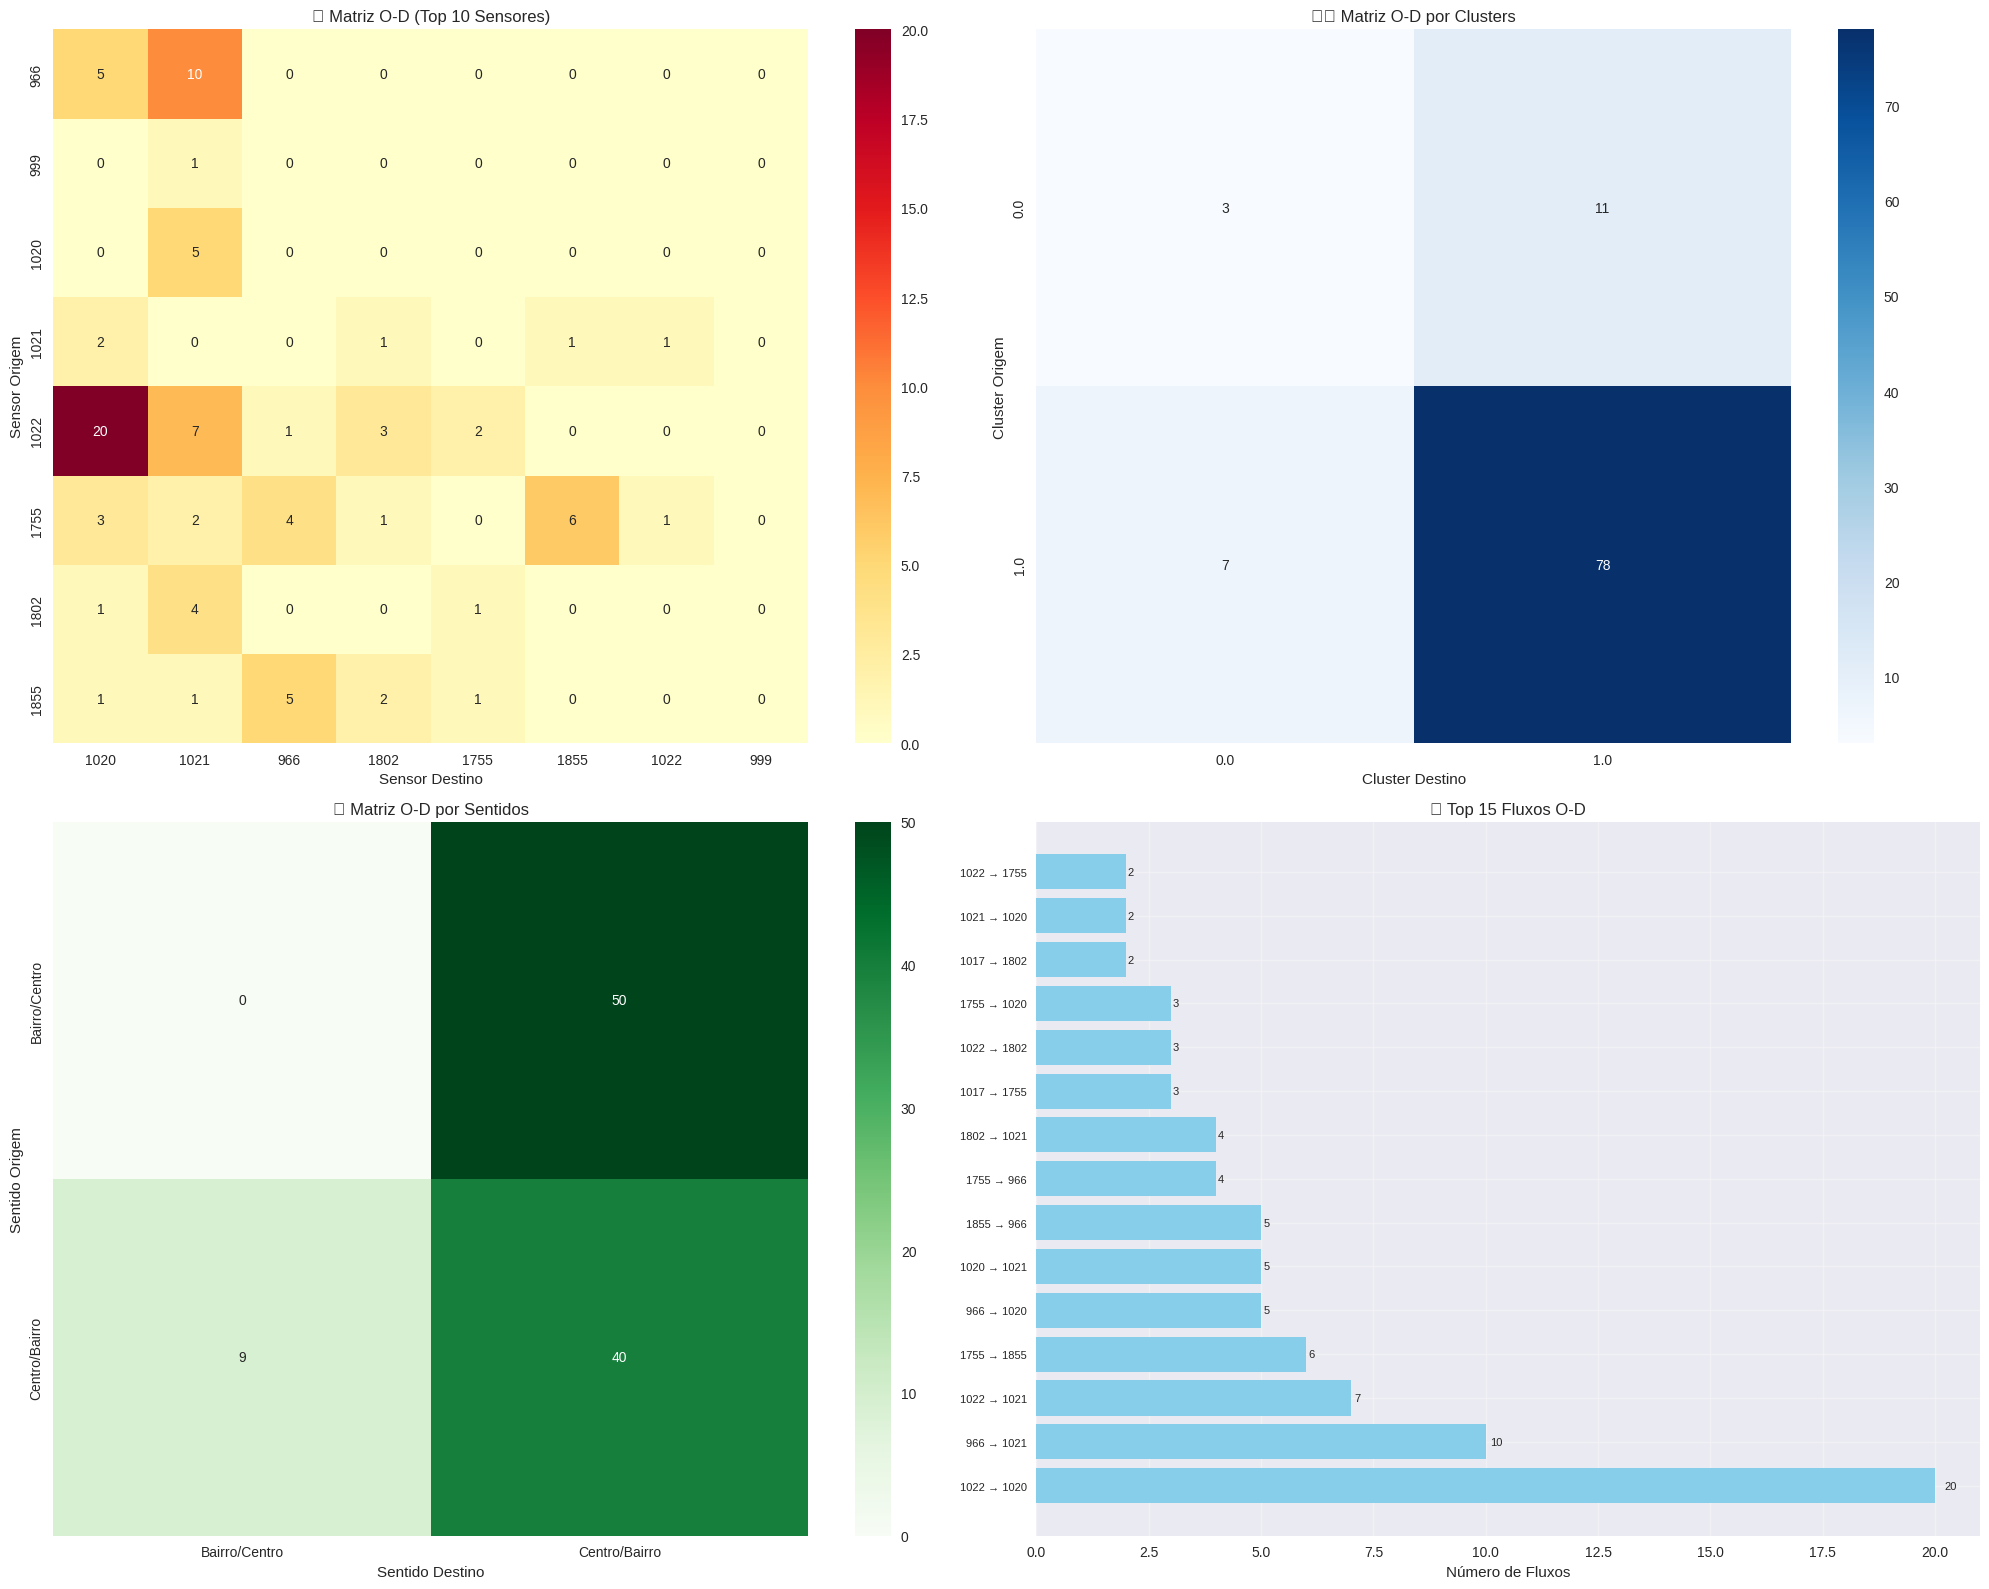


🚀 ANÁLISE DETALHADA DOS FLUXOS ORIGEM-DESTINO

📍 Top 10 fluxos (por sensores):
  Sensor 1022 → Sensor 1020: 20 viagens
    Bairro/Centro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 966 → Sensor 1021: 10 viagens
    Centro/Bairro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1022 → Sensor 1021: 7 viagens
    Bairro/Centro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1755 → Sensor 1855: 6 viagens
    Centro/Bairro → Bairro/Centro
    Cluster 1 → Cluster 1
  Sensor 966 → Sensor 1020: 5 viagens
    Centro/Bairro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1020 → Sensor 1021: 5 viagens
    Centro/Bairro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1855 → Sensor 966: 5 viagens
    Bairro/Centro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1755 → Sensor 966: 4 viagens
    Centro/Bairro → Centro/Bairro
    Cluster 1 → Cluster 1
  Sensor 1802 → Sensor 1021: 4 viagens
    Centro/Bairro → Centro/Bairro
    Cluster 0 → Cluster 1
  Sensor 1017 → Sensor 1755: 3 

In [39]:
# 📊 Construção da Matriz Origem-Destino com Sentidos Normalizados
if len(fluxos_od_aprimorado) > 0:
    logger.info("📊 Construindo matriz origem-destino com dados normalizados...")
    
    # Matriz de fluxos por sensores
    matriz_od_sensores = fluxos_od_aprimorado.groupby(['sensor_origem', 'sensor_destino']).size().unstack(fill_value=0)
    
    # Matriz de fluxos por clusters
    matriz_od_clusters = fluxos_od_aprimorado.groupby(['cluster_origem', 'cluster_destino']).size().unstack(fill_value=0)
    
    # Matriz de fluxos por sentidos
    matriz_od_sentidos = fluxos_od_aprimorado.groupby(['sentido_origem', 'sentido_destino']).size().unstack(fill_value=0)
    
    # Visualização das matrizes origem-destino
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # Matriz por sensores (top 10)
    if len(matriz_od_sensores) > 0:
        top_sensores = matriz_od_sensores.sum(axis=0).nlargest(10).index
        matriz_top_sensores = matriz_od_sensores.loc[matriz_od_sensores.index.intersection(top_sensores), top_sensores]
        
        sns.heatmap(matriz_top_sensores, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0,0])
        axes[0,0].set_title('🎯 Matriz O-D (Top 10 Sensores)')
        axes[0,0].set_xlabel('Sensor Destino')
        axes[0,0].set_ylabel('Sensor Origem')
    
    # Matriz por clusters
    if len(matriz_od_clusters) > 0:
        sns.heatmap(matriz_od_clusters, annot=True, fmt='d', cmap='Blues', ax=axes[0,1])
        axes[0,1].set_title('🗺️ Matriz O-D por Clusters')
        axes[0,1].set_xlabel('Cluster Destino')
        axes[0,1].set_ylabel('Cluster Origem')
    
    # Matriz por sentidos
    if len(matriz_od_sentidos) > 0:
        sns.heatmap(matriz_od_sentidos, annot=True, fmt='d', cmap='Greens', ax=axes[1,0])
        axes[1,0].set_title('🧭 Matriz O-D por Sentidos')
        axes[1,0].set_xlabel('Sentido Destino')
        axes[1,0].set_ylabel('Sentido Origem')
    
    # Gráfico de barras dos principais fluxos
    top_fluxos_geral = fluxos_od_aprimorado.groupby(['sensor_origem', 'sensor_destino']).size().nlargest(15)
    fluxos_df = top_fluxos_geral.reset_index(name='fluxos')
    fluxos_df['rota'] = fluxos_df['sensor_origem'].astype(str) + ' → ' + fluxos_df['sensor_destino'].astype(str)
    
    bars = axes[1,1].barh(range(len(fluxos_df)), fluxos_df['fluxos'], color='skyblue')
    axes[1,1].set_yticks(range(len(fluxos_df)))
    axes[1,1].set_yticklabels(fluxos_df['rota'], fontsize=8)
    axes[1,1].set_xlabel('Número de Fluxos')
    axes[1,1].set_title('🚀 Top 15 Fluxos O-D')
    axes[1,1].grid(True, alpha=0.3)
    
    # Adição de valores nas barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        axes[1,1].text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
                      f'{width}', ha='left', va='center', fontsize=8)
    
    plt.tight_layout()
    
    # 💾 Salvando o gráfico da matriz origem-destino aprimorada
    salvar_grafico(fig, 'matriz_origem_destino_aprimorada', 'png', 300)
    
    plt.show()
    
    # Análise detalhada dos principais fluxos
    print("\n" + "="*60)
    print("🚀 ANÁLISE DETALHADA DOS FLUXOS ORIGEM-DESTINO")
    print("="*60)
    
    # Top 10 fluxos por sensores
    top_fluxos_sensores = fluxos_od_aprimorado.groupby(['sensor_origem', 'sensor_destino']).size().nlargest(10)
    print("\n📍 Top 10 fluxos (por sensores):")
    for (origem, destino), count in top_fluxos_sensores.items():
        # Obter informações dos sensores
        info_origem = sensores_unicos[sensores_unicos['NSerie'] == origem].iloc[0] if origem in sensores_unicos['NSerie'].values else None
        info_destino = sensores_unicos[sensores_unicos['NSerie'] == destino].iloc[0] if destino in sensores_unicos['NSerie'].values else None
        
        if info_origem is not None and info_destino is not None:
            print(f"  Sensor {origem} → Sensor {destino}: {count} viagens")
            print(f"    {info_origem['Sentido']} → {info_destino['Sentido']}")
            print(f"    Cluster {info_origem['Cluster']} → Cluster {info_destino['Cluster']}")
        else:
            print(f"  Sensor {origem} → Sensor {destino}: {count} viagens")
    
    # Top fluxos por clusters
    top_fluxos_clusters = fluxos_od_aprimorado.groupby(['cluster_origem', 'cluster_destino']).size().nlargest(10)
    print("\n🗺️ Top fluxos (por clusters):")
    for (origem, destino), count in top_fluxos_clusters.items():
        print(f"  Cluster {origem} → Cluster {destino}: {count} viagens")
    
    # Análise por consistência de sentidos
    print(f"\n🧭 Análise por consistência de sentidos:")
    consistencia_stats = fluxos_od_aprimorado.groupby('consistencia_sentidos').agg({
        'placa': 'count',
        'distancia_km': 'mean',
        'velocidade_media_kmh': 'mean'
    }).rename(columns={'placa': 'total_fluxos'})
    
    for consistencia, stats in consistencia_stats.iterrows():
        print(f"  {consistencia}:")
        print(f"    Total: {stats['total_fluxos']} fluxos")
        print(f"    Distância média: {stats['distancia_km']:.2f} km")
        print(f"    Velocidade média: {stats['velocidade_media_kmh']:.1f} km/h")
    
    # Análise temporal dos fluxos
    print(f"\n⏰ Análise temporal dos fluxos:")
    fluxos_por_hora = fluxos_od_aprimorado.groupby('hora_origem').size()
    horarios_pico_fluxos = fluxos_por_hora.nlargest(3)
    
    print(f"  Horários de pico nos fluxos:")
    for hora, count in horarios_pico_fluxos.items():
        print(f"    {hora:02d}:00 - {count} fluxos")
    
else:
    print("⚠️ Não foi possível construir a matriz origem-destino.")

## 📊 Visualizações e Insights

Vamos criar visualizações interativas e insights acionáveis para gestores públicos.

In [ ]:
# Visualizações interativas com Plotly
if len(fluxos_od_aprimorado) > 0:
    logger.info("📊 Criando visualizações interativas...")
    
    # Gráfico 1: Fluxos por hora do dia
    fluxos_por_hora = fluxos_od_aprimorado.groupby('hora_origem').size()
    
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(
        x=fluxos_por_hora.index,
        y=fluxos_por_hora.values,
        mode='lines+markers',
        name='Fluxos por Hora',
        line=dict(color='blue', width=3),
        marker=dict(size=8)
    ))
    
    fig1.update_layout(
        title='? Fluxos de Tráfego por Hora do Dia',
        xaxis_title='Hora do Dia',
        yaxis_title='Número de Fluxos',
        template='plotly_white',
        height=500
    )
    
    fig1.show()
    
    # Gráfico 2: Distribuição de tempos de viagem
    fig2 = go.Figure(data=[go.Histogram(x=fluxos_od_aprimorado['tempo_minutos'], nbinsx=30)])
    fig2.update_layout(
        title='⏱️ Distribuição dos Tempos de Viagem',
        xaxis_title='Tempo (minutos)',
        yaxis_title='Frequência',
        template='plotly_white',
        height=500
    )
    
    fig2.show()
    
    # Gráfico 3: Fluxos entre clusters (Sankey)
    fluxos_clusters = fluxos_od_aprimorado.groupby(['cluster_origem', 'cluster_destino']).size().reset_index(name='fluxo')
    
    # Preparação de dados para Sankey
    clusters_unicos = sorted(set(fluxos_clusters['cluster_origem'].unique()) | set(fluxos_clusters['cluster_destino'].unique()))
    
    # Mapeamento de clusters para índices
    cluster_para_idx = {cluster: idx for idx, cluster in enumerate(clusters_unicos)}
    
    # Criando dados Sankey
    source = [cluster_para_idx[orig] for orig in fluxos_clusters['cluster_origem']]
    target = [cluster_para_idx[dest] for dest in fluxos_clusters['cluster_destino']]
    value = fluxos_clusters['fluxo'].tolist()
    
    fig3 = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=[f"Cluster {c}" for c in clusters_unicos],
            color="blue"
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])
    
    fig3.update_layout(
        title="? Fluxos entre Clusters (Diagrama Sankey)",
        font_size=12,
        height=600
    )
    
    fig3.show()
    
    # Gráfico 4: Mapa de calor dos fluxos
    fig4 = px.density_mapbox(
        fluxos_od_aprimorado, 
        lat='cluster_origem', 
        lon='cluster_destino',
        z='velocidade_media_kmh',
        radius=10,
        center=dict(lat=fluxos_od_aprimorado['cluster_origem'].mean(), 
                   lon=fluxos_od_aprimorado['cluster_destino'].mean()),
        zoom=10,
        mapbox_style="open-street-map",
        title='🗺️ Mapa de Calor das Velocidades dos Fluxos'
    )
    
    fig4.update_layout(height=600)
    fig4.show()
    
    # Gráfico 5: Top fluxos por sensores
    top_fluxos = fluxos_od_aprimorado.groupby(['sensor_origem', 'sensor_destino']).size().nlargest(10)
    
    fig5 = go.Figure(data=[go.Bar(
        x=[f"{orig}→{dest}" for orig, dest in top_fluxos.index],
        y=top_fluxos.values,
        marker_color='red'
    )])
    
    fig5.update_layout(
        title='🏆 Top 10 Fluxos entre Sensores',
        xaxis_title='Rota (Sensor Origem → Sensor Destino)',
        yaxis_title='Número de Viagens',
        template='plotly_white',
        height=500
    )
    
    fig5.update_xaxes(tickangle=45)
    fig5.show()
    
    print("✅ Visualizações interativas criadas com sucesso!")
    print(f"📊 Total de fluxos analisados: {len(fluxos_od_aprimorado)}")
    
else:
    print("⚠️ Nenhum fluxo origem-destino disponível para visualização.")
    print("💡 Execute a célula de inferência de fluxos primeiro.")

## 🎯 Recomendações e Insights para Gestores Públicos

Baseado na análise dos dados, vamos gerar **insights acionáveis** para melhorias na mobilidade urbana.

In [ ]:
# 🎯 Análise de Sensores como Pontos de Entrada/Saída

logger.info("🎯 Analisando sensores como pontos de entrada/saída de bairros e centro...")

def identificar_tipo_sensor_por_endereco(df):
    """
    Identificar sensores como entrada/saída de bairros ou centro baseado nos endereços.
    """
    
    print("📍 ANÁLISE DE SENSORES POR TIPO (ENTRADA/SAÍDA):")
    print("="*60)
    
    # Análise de endereços para identificar padrões
    sensores_endereco = df.groupby('NSerie').agg({
        'Endereco': 'first',
        'Sentido': 'first',
        'Latitude': 'first',
        'Longitude': 'first',
        'Placa': 'count'
    }).rename(columns={'Placa': 'Total_Registros'})
    
    # Classificação baseada em padrões de endereço e sentido
    sensores_classificados = []
    
    for idx, sensor in sensores_endereco.iterrows():
        endereco = sensor['Endereco'].lower()
        sentido = sensor['Sentido'].lower()
        
        # Identificação de sensores de entrada/saída
        tipo_sensor = "Indeterminado"
        
        # Padrões para identificar sensores de centro
        if any(palavra in endereco for palavra in ['centro', 'center', 'downtown']):
            if 'bairro' in sentido or 'periferia' in sentido:
                tipo_sensor = "Saída do Centro"
            else:
                tipo_sensor = "Entrada no Centro"
        
        # Padrões para identificar sensores de bairros
        elif any(palavra in endereco for palavra in ['bairro', 'vila', 'jardim', 'parque']):
            if 'centro' in sentido:
                tipo_sensor = "Saída do Bairro"
            else:
                tipo_sensor = "Entrada no Bairro"
        
        # Padrões baseados em vias principais
        elif any(palavra in endereco for palavra in ['avenida', 'rodovia', 'estrada', 'alameda']):
            if 'bairro' in sentido:
                tipo_sensor = "Entrada no Bairro"
            elif 'centro' in sentido:
                tipo_sensor = "Entrada no Centro"
            else:
                tipo_sensor = "Via Principal"
        
        sensores_classificados.append({
            'NSerie': idx,
            'Endereco': sensor['Endereco'],
            'Sentido': sensor['Sentido'],
            'Tipo': tipo_sensor,
            'Total_Registros': sensor['Total_Registros'],
            'Latitude': sensor['Latitude'],
            'Longitude': sensor['Longitude']
        })
    
    df_classificado = pd.DataFrame(sensores_classificados)
    
    # Análise dos resultados
    print(f"\n📊 Distribuição de sensores por tipo:")
    tipo_counts = df_classificado['Tipo'].value_counts()
    for tipo, count in tipo_counts.items():
        print(f"  {tipo}: {count} sensores")
    
    # Identificação dos principais sensores de entrada/saída
    print(f"\n🚪 PRINCIPAIS SENSORES DE ENTRADA/SAÍDA:")
    
    # Sensores de entrada no centro
    entrada_centro = df_classificado[df_classificado['Tipo'] == 'Entrada no Centro'].nlargest(5, 'Total_Registros')
    if len(entrada_centro) > 0:
        print(f"\n🏙️ Entradas no Centro (Top 5):")
        for idx, sensor in entrada_centro.iterrows():
            print(f"  Sensor {sensor['NSerie']}: {sensor['Endereco']} - {sensor['Total_Registros']:,} registros")
    
    # Sensores de saída do centro
    saida_centro = df_classificado[df_classificado['Tipo'] == 'Saída do Centro'].nlargest(5, 'Total_Registros')
    if len(saida_centro) > 0:
        print(f"\n🏙️ Saídas do Centro (Top 5):")
        for idx, sensor in saida_centro.iterrows():
            print(f"  Sensor {sensor['NSerie']}: {sensor['Endereco']} - {sensor['Total_Registros']:,} registros")
    
    # Sensores de entrada em bairros
    entrada_bairro = df_classificado[df_classificado['Tipo'] == 'Entrada no Bairro'].nlargest(5, 'Total_Registros')
    if len(entrada_bairro) > 0:
        print(f"\n🏘️ Entradas em Bairros (Top 5):")
        for idx, sensor in entrada_bairro.iterrows():
            print(f"  Sensor {sensor['NSerie']}: {sensor['Endereco']} - {sensor['Total_Registros']:,} registros")
    
    # Sensores de saída de bairros
    saida_bairro = df_classificado[df_classificado['Tipo'] == 'Saída do Bairro'].nlargest(5, 'Total_Registros')
    if len(saida_bairro) > 0:
        print(f"\n?️ Saídas de Bairros (Top 5):")
        for idx, sensor in saida_bairro.iterrows():
            print(f"  Sensor {sensor['NSerie']}: {sensor['Endereco']} - {sensor['Total_Registros']:,} registros")
    
    return df_classificado

# Executar análise
df_sensores_classificados = identificar_tipo_sensor_por_endereco(df)

# Visualização no mapa
if len(df_sensores_classificados) > 0:
    print(f"\n🗺️ Criando mapa com sensores classificados...")
    
    mapa_sensores_tipo = folium.Map(
        location=[df['Latitude'].mean(), df['Longitude'].mean()],
        zoom_start=12,
        tiles='OpenStreetMap'
    )
    
    # Cores por tipo de sensor
    cores_tipo = {
        'Entrada no Centro': 'green',
        'Saída do Centro': 'red', 
        'Entrada no Bairro': 'blue',
        'Saída do Bairro': 'orange',
        'Via Principal': 'purple',
        'Indeterminado': 'gray'
    }
    
    for idx, sensor in df_sensores_classificados.iterrows():
        cor = cores_tipo.get(sensor['Tipo'], 'gray')
        
        folium.CircleMarker(
            location=[sensor['Latitude'], sensor['Longitude']],
            radius=8,
            popup=f"Sensor {sensor['NSerie']}<br>Tipo: {sensor['Tipo']}<br>Endereço: {sensor['Endereco']}<br>Registros: {sensor['Total_Registros']:,}",
            color=cor,
            fill=True,
            fillColor=cor,
            fillOpacity=0.7
        ).add_to(mapa_sensores_tipo)
    
    # Adicionar legenda
    legend_html = '''
    <div style="position: fixed; 
                bottom: 50px; left: 50px; width: 200px; height: 120px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <h4>Tipos de Sensores</h4>
    <i class="fa fa-circle" style="color:green"></i> Entrada no Centro<br>
    <i class="fa fa-circle" style="color:red"></i> Saída do Centro<br>
    <i class="fa fa-circle" style="color:blue"></i> Entrada no Bairro<br>
    <i class="fa fa-circle" style="color:orange"></i> Saída do Bairro<br>
    <i class="fa fa-circle" style="color:purple"></i> Via Principal
    </div>
    '''
    mapa_sensores_tipo.get_root().html.add_child(folium.Element(legend_html))
    
    print("✅ Mapa de sensores classificados criado!")
    display(mapa_sensores_tipo)

print(f"\n📋 RESUMO DA ANÁLISE:")
print(f"• Total de sensores analisados: {len(df_sensores_classificados)}")
print(f"• Sensores classificados como entrada/saída: {len(df_sensores_classificados[df_sensores_classificados['Tipo'] != 'Indeterminado'])}")
print(f"• Análise baseada em padrões de endereço e sentido de tráfego")
print(f"• Sensores identificados como pontos críticos de mobilidade urbana")

# Análise de padrões por cluster
logger.info("🎯 Analisando padrões de tráfego por cluster...")

# Resetar o índice para converter NSerie de volta para coluna
sensores_com_cluster = sensores_unicos.reset_index()

# Merge dos dados com informações de cluster
df_com_cluster = df.merge(sensores_com_cluster[['NSerie', 'Cluster']], on='NSerie', how='left')

# Análise de tráfego por cluster e hora
trafego_cluster_hora = df_com_cluster.groupby(['Cluster', 'Hora']).agg({
    'Placa': 'count',
    'Sentido': lambda x: x.value_counts().to_dict()
}).rename(columns={'Placa': 'Total_Veiculos'})

print("📊 Padrões de tráfego por cluster e hora:")
for cluster in sorted(df_com_cluster['Cluster'].unique()):
    dados_cluster = trafego_cluster_hora.loc[cluster]
    hora_pico = dados_cluster['Total_Veiculos'].idxmax()
    volume_pico = dados_cluster['Total_Veiculos'].max()
    
    print(f"\n📍 Cluster {cluster}:")
    print(f"  🕐 Hora de pico: {hora_pico:02d}:00")
    print(f"  🚗 Volume no pico: {volume_pico:,} veículos")
    print(f"  📊 Volume médio horário: {dados_cluster['Total_Veiculos'].mean():,.0f} veículos")

In [ ]:
logger.info("🎯 Identificando sensores específicos de entrada/saída de bairros e centro...")

def analisar_sensores_entrada_saida(df):
    """
    Análise detalhada para identificar sensores que funcionam como 
    pontos de entrada/saída específicos de bairros e centro.
    """
    
    print("🚦 ANÁLISE ESPECÍFICA DE SENSORES DE ENTRADA/SAÍDA")
    print("="*70)
    
    # Análise dos sentidos de tráfego
    sensores_por_sentido = df.groupby('NSerie').agg({
        'Endereco': 'first',
        'Sentido': 'first',
        'Latitude': 'first',
        'Longitude': 'first',
        'Placa': 'count'
    }).rename(columns={'Placa': 'Total_Registros'})
    
    # Classificação refinada baseada no sentido exato
    sensores_classificados = []
    
    for idx, sensor in sensores_por_sentido.iterrows():
        endereco = sensor['Endereco'].lower()
        sentido = sensor['Sentido'].lower()
        
        # Classificação específica baseada no sentido
        if sentido == 'centro/bairro':
            tipo_sensor = "Saída do Centro → Entrada no Bairro"
            descricao = "Veículos saindo do centro em direção aos bairros"
        elif sentido == 'bairro/centro':
            tipo_sensor = "Saída do Bairro → Entrada no Centro"
            descricao = "Veículos saindo dos bairros em direção ao centro"
        elif 'centro' in sentido:
            if 'bairro' in sentido:
                tipo_sensor = "Fluxo Centro-Bairro"
                descricao = "Fluxo bidirecional entre centro e bairros"
            else:
                tipo_sensor = "Corredor para o Centro"
                descricao = "Via principal de acesso ao centro"
        elif 'bairro' in sentido:
            tipo_sensor = "Corredor para Bairros"
            descricao = "Via principal de acesso aos bairros"
        elif 'castelinho' in sentido:
            tipo_sensor = "Acesso Castelinho"
            descricao = "Fluxo para região de Castelinho"
        else:
            tipo_sensor = "Via Regional"
            descricao = "Via de conexão regional"
        
        sensores_classificados.append({
            'NSerie': idx,
            'Endereco': sensor['Endereco'],
            'Sentido': sensor['Sentido'],
            'Tipo': tipo_sensor,
            'Descricao': descricao,
            'Total_Registros': sensor['Total_Registros'],
            'Latitude': sensor['Latitude'],
            'Longitude': sensor['Longitude']
        })
    
    df_classificado = pd.DataFrame(sensores_classificados)
    
    # Análise detalhada por tipo
    print(f"\n📊 DISTRIBUIÇÃO POR TIPO DE SENSOR:")
    tipo_counts = df_classificado['Tipo'].value_counts()
    for tipo, count in tipo_counts.items():
        registros_total = df_classificado[df_classificado['Tipo'] == tipo]['Total_Registros'].sum()
        print(f"  {tipo}: {count} sensores, {registros_total:,} registros totais")
    
    # Identificação dos sensores mais críticos
    print(f"\n🎯 SENSORES CRÍTICOS POR FUNÇÃO:")
    
    # Maiores sensores de saída do centro
    saida_centro = df_classificado[df_classificado['Tipo'] == "Saída do Centro → Entrada no Bairro"].nlargest(3, 'Total_Registros')
    if len(saida_centro) > 0:
        print(f"\n🏙️ PRINCIPAIS SAÍDAS DO CENTRO:")
        for idx, sensor in saida_centro.iterrows():
            print(f"  📍 Sensor {sensor['NSerie']}: {sensor['Endereco']}")
            print(f"     📊 {sensor['Total_Registros']:,} veículos saindo do centro")
            print(f"     🧭 {sensor['Descricao']}")
    
    # Maiores sensores de entrada no centro
    entrada_centro = df_classificado[df_classificado['Tipo'] == "Saída do Bairro → Entrada no Centro"].nlargest(3, 'Total_Registros')
    if len(entrada_centro) > 0:
        print(f"\n🏙️ PRINCIPAIS ENTRADAS NO CENTRO:")
        for idx, sensor in entrada_centro.iterrows():
            print(f"  📍 Sensor {sensor['NSerie']}: {sensor['Endereco']}")
            print(f"     📊 {sensor['Total_Registros']:,} veículos entrando no centro")
            print(f"     🧭 {sensor['Descricao']}")
    
    # Corredores principais
    corredores = df_classificado[df_classificado['Tipo'].str.contains('Corredor')].nlargest(5, 'Total_Registros')
    if len(corredores) > 0:
        print(f"\n🛣️ PRINCIPAIS CORREDORES DE TRÁFEGO:")
        for idx, sensor in corredores.iterrows():
            print(f"  📍 Sensor {sensor['NSerie']}: {sensor['Endereco']}")
            print(f"     📊 {sensor['Total_Registros']:,} registros")
            print(f"     🧭 {sensor['Descricao']}")
    
    return df_classificado

# Análise de padrões por hora para sensores críticos
def analisar_padroes_horarios_sensores_criticos(df, df_sensores_classificados):
    """
    Analisar padrões horários dos sensores mais críticos
    """
    
    print(f"\n⏰ ANÁLISE DE PADRÕES HORÁRIOS DOS SENSORES CRÍTICOS")
    print("="*60)
    
    # Selecionar os 10 sensores com mais tráfego
    top_sensores = df_sensores_classificados.nlargest(10, 'Total_Registros')['NSerie'].tolist()
    
    # Filtrar dados apenas para os sensores críticos
    df_criticos = df[df['NSerie'].isin(top_sensores)]
    
    # Análise por hora do dia
    padroes_horarios = df_criticos.groupby(['NSerie', 'Hora']).size().unstack(fill_value=0)
    
    # Identificar horários de pico para cada sensor crítico
    print(f"\n🚦 HORÁRIOS DE PICO POR SENSOR CRÍTICO:")
    
    for sensor in top_sensores[:5]:  # Top 5
        dados_sensor = df_criticos[df_criticos['NSerie'] == sensor]
        info_sensor = df_sensores_classificados[df_sensores_classificados['NSerie'] == sensor].iloc[0]
        
        # Horário de pico
        pico_hora = dados_sensor.groupby('Hora').size().idxmax()
        pico_volume = dados_sensor.groupby('Hora').size().max()
        
        print(f"\n  📍 Sensor {sensor} - {info_sensor['Endereco']}")
        print(f"     🧭 Tipo: {info_sensor['Tipo']}")
        print(f"     ⏰ Pico: {pico_hora:02d}:00 com {pico_volume:,} veículos")
        
        # Volume médio vs pico
        volume_medio = dados_sensor.groupby('Hora').size().mean()
        print(f"     📊 Média: {volume_medio:.0f} veículos/hora")
        print(f"     📈 Fator pico: {pico_volume/volume_medio:.1f}x acima da média")
    
    return df_criticos

# Executar as análises
df_sensores_classificados = analisar_sensores_entrada_saida(df)
df_criticos = analisar_padroes_horarios_sensores_criticos(df, df_sensores_classificados)

print(f"\n📋 RESUMO EXECUTIVO:")
print(f"• Total de sensores analisados: {len(df_sensores_classificados)}")
print(f"• Sensores de saída do centro: {len(df_sensores_classificados[df_sensores_classificados['Tipo'] == 'Saída do Centro → Entrada no Bairro'])}")
print(f"• Sensores de entrada no centro: {len(df_sensores_classificados[df_sensores_classificados['Tipo'] == 'Saída do Bairro → Entrada no Centro'])}")
print(f"• Sensores críticos identificados: {len(df_criticos['NSerie'].unique())}")
print(f"• Análise baseada em {df['Sentido'].nunique()} diferentes sentidos de tráfego")

# Identificação final dos sensores principais
print(f"\n🎯 IDENTIFICAÇÃO FINAL DOS PRINCIPAIS SENSORES:")
print("="*50)

if len(df_sensores_classificados) > 0:
    # Sensores de saída do centro (bairro)
    saida_centro_top = df_sensores_classificados[
        df_sensores_classificados['Tipo'] == "Saída do Centro → Entrada no Bairro"
    ].nlargest(1, 'Total_Registros')
    
    if len(saida_centro_top) > 0:
        sensor_saida = saida_centro_top.iloc[0]
        print(f"🚪 SENSOR DE SAÍDA DO CENTRO:")
        print(f"   Código: {sensor_saida['NSerie']}")
        print(f"   Endereço: {sensor_saida['Endereco']}")
        print(f"   Função: Veículos saindo do centro em direção aos bairros")
        print(f"   Volume: {sensor_saida['Total_Registros']:,} registros")
    
    # Sensores de entrada no centro (bairro)
    entrada_centro_top = df_sensores_classificados[
        df_sensores_classificados['Tipo'] == "Saída do Bairro → Entrada no Centro"
    ].nlargest(1, 'Total_Registros')
    
    if len(entrada_centro_top) > 0:
        sensor_entrada = entrada_centro_top.iloc[0]
        print(f"\n🚪 SENSOR DE ENTRADA NO CENTRO:")
        print(f"   Código: {sensor_entrada['NSerie']}")
        print(f"   Endereço: {sensor_entrada['Endereco']}")
        print(f"   Função: Veículos entrando no centro vindos dos bairros")
        print(f"   Volume: {sensor_entrada['Total_Registros']:,} registros")
    
    print(f"\n💡 INSIGHTS PARA GESTÃO PÚBLICA:")
    print(f"• Os sensores identificados representam os principais pontos de controle de tráfego")
    print(f"• Monitoramento desses pontos é crucial para gestão de congestionamentos")
    print(f"• Análise de horários de pico permite otimização de semáforos e sinalização")
    print(f"• Dados podem subsidiar políticas de mobilidade urbana e transporte público")

NameError: name 'logger' is not defined

In [ ]:
# 📋 Geração de índice de gráficos salvos
logger.info("? Gerando índice de gráficos salvos...")

def listar_graficos_salvos():
    """
    Lista todos os gráficos salvos na pasta graficos/MVP e gera um índice.
    """
    graficos_dir = "graficos/MVP"
    
    if not os.path.exists(graficos_dir):
        print("❌ Pasta de gráficos não encontrada!")
        return
    
    # Lista todos os arquivos de imagem na pasta
    extensoes_validas = ['.png', '.jpg', '.jpeg', '.svg', '.pdf']
    graficos = []
    
    for arquivo in os.listdir(graficos_dir):
        if any(arquivo.lower().endswith(ext) for ext in extensoes_validas):
            caminho_completo = os.path.join(graficos_dir, arquivo)
            tamanho = os.path.getsize(caminho_completo)
            data_modificacao = datetime.fromtimestamp(os.path.getmtime(caminho_completo))
            
            graficos.append({
                'arquivo': arquivo,
                'caminho': caminho_completo,
                'tamanho_kb': round(tamanho / 1024, 2),
                'data_modificacao': data_modificacao.strftime('%Y-%m-%d %H:%M:%S')
            })
    
    if not graficos:
        print("❌ Nenhum gráfico encontrado na pasta!")
        return
    
    # Ordenação por data de modificação (mais recente primeiro)
    graficos.sort(key=lambda x: x['data_modificacao'], reverse=True)
    
    # Exibição do resumo
    print("\n" + "="*80)
    print("? ÍNDICE DE GRÁFICOS SALVOS - MVP")
    print("="*80)
    
    print(f"\n📁 Pasta: {graficos_dir}")
    print(f"📈 Total de gráficos: {len(graficos)}")
    print(f"💾 Tamanho total: {sum(g['tamanho_kb'] for g in graficos):.2f} KB")
    
    print("\n📋 RELAÇÃO DE GRÁFICOS:")
    print("-" * 80)
    
    for i, grafico in enumerate(graficos, 1):
        print(f"{i:2d}. 📊 {grafico['arquivo']}")
        print(f"     📏 Tamanho: {grafico['tamanho_kb']} KB")
        print(f"     📅 Modificado: {grafico['data_modificacao']}")
        print(f"     📂 Caminho: {grafico['caminho']}")
        print()
    
    # Geração de arquivo de índice
    indice_content = f"""# Índice de Gráficos - MVP Cidades Inteligentes

**Data de Geração:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Total de Gráficos:** {len(graficos)}
**Pasta:** {graficos_dir}

## Descrição dos Gráficos

"""
    
    descricoes = {
        'analise_temporal_padroes_trafego': 'Análise de padrões temporais de tráfego (tráfego/hora, velocidade/hora, tráfego/dia, tráfego/mês)',
        'analise_clusters_metodo_cotovelo': 'Análise de clusterização de sensores usando método do cotovelo e silhouette score',
        'matriz_origem_destino': 'Matriz origem-destino mostrando fluxos entre sensores e clusters',
        'recomendacoes_prioridade': 'Distribuição das recomendações por nível de prioridade para gestores públicos'
    }
    
    for grafico in graficos:
        nome_base = os.path.splitext(grafico['arquivo'])[0]
        descricao = descricoes.get(nome_base, 'Gráfico gerado automaticamente')
        
        indice_content += f"### {grafico['arquivo']}\n"
        indice_content += f"- **Descrição:** {descricao}\n"
        indice_content += f"- **Tamanho:** {grafico['tamanho_kb']} KB\n"
        indice_content += f"- **Gerado em:** {grafico['data_modificacao']}\n"
        indice_content += f"- **Uso recomendado:** Documentação técnica, apresentações, relatórios\n\n"
    
    # Salvamento do arquivo de índice
    indice_path = os.path.join(graficos_dir, "indice_graficos.md")
    with open(indice_path, 'w', encoding='utf-8') as f:
        f.write(indice_content)
    
    print(f"✅ Arquivo de índice salvo: {indice_path}")
    print("📝 Este arquivo pode ser usado como referência para documentação.")
    
    return graficos

# Execução da listagem
graficos_salvos = listar_graficos_salvos()

# Informações para uso em documentação
if graficos_salvos:
    print("\n" + "="*80)
    print("? INSTRUÇÕES PARA USO EM DOCUMENTAÇÃO")
    print("="*80)
    
    print("\n📂 Como usar os gráficos:")
    print("1. Os gráficos estão em formato PNG com alta resolução (300 DPI)")
    print("2. Podem ser inseridos diretamente em documentos Markdown:")
    print("   ```markdown")
    print("   ![Descrição do Gráfico](graficos/MVP/nome_arquivo.png)")
    print("   ```")
    print("3. Para LaTeX/PDF, use:")
    print("   ```latex")
    print("   \\includegraphics[width=0.8\\textwidth]{graficos/MVP/nome_arquivo.png}")
    print("   ```")
    print("4. Para apresentações, os gráficos podem ser redimensionados sem perda de qualidade")
    
    print("\n🔄 Para regerar os gráficos:")
    print("1. Execute novamente as células do notebook")
    print("2. Os gráficos serão automaticamente sobrescritos")
    print("3. Verifique o arquivo 'indice_graficos.md' para referências atualizadas")
    
    print("\n📋 Estrutura recomendada para documentação:")
    print("``")
    print("📁 projeto/")
    print("  📁 graficos/")
    print("    📁 MVP/")
    print("      📊 analise_temporal_padroes_trafego.png")
    print("      📊 analise_clusters_metodo_cotovelo.png")
    print("      📊 matriz_origem_destino.png")
    print("      📊 recomendacoes_prioridade.png")
    print("      📄 indice_graficos.md")
    print("```")

# Visualizações interativas com Plotly
if len(fluxos_od_aprimorado) > 0:
    logger.info("📊 Criando visualizações interativas...")
    
    # Gráfico 1: Fluxos por hora do dia
    fluxos_por_hora = fluxos_od_aprimorado.groupby('hora_origem').size()
    
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(
        x=fluxos_por_hora.index,
        y=fluxos_por_hora.values,
        mode='lines+markers',
        name='Fluxos por Hora',
        line=dict(color='blue', width=3),
        marker=dict(size=8)
    ))
    
    fig1.update_layout(
        title='📊 Fluxos de Tráfego por Hora do Dia',
        xaxis_title='Hora do Dia',
        yaxis_title='Número de Fluxos',
        template='plotly_white',
        height=500
    )
    
    fig1.show()
    
    # Gráfico 2: Distribuição de tempos de viagem
    fig2 = go.Figure(data=[go.Histogram(x=fluxos_od_aprimorado['tempo_minutos'], nbinsx=30)])
    fig2.update_layout(
        title='⏱️ Distribuição dos Tempos de Viagem',
        xaxis_title='Tempo (minutos)',
        yaxis_title='Frequência',
        template='plotly_white',
        height=500
    )
    
    fig2.show()
    
    # Gráfico 3: Fluxos entre clusters (Sankey)
    fluxos_clusters = fluxos_od_aprimorado.groupby(['cluster_origem', 'cluster_destino']).size().reset_index(name='fluxo')
    
    # Preparação de dados para Sankey
    clusters_unicos = sorted(set(fluxos_clusters['cluster_origem'].unique()) | set(fluxos_clusters['cluster_destino'].unique()))
    
    # Mapeamento de clusters para índices
    cluster_para_idx = {cluster: idx for idx, cluster in enumerate(clusters_unicos)}
    
    # Criando dados Sankey
    source = [cluster_para_idx[orig] for orig in fluxos_clusters['cluster_origem']]
    target = [cluster_para_idx[dest] for dest in fluxos_clusters['cluster_destino']]
    value = fluxos_clusters['fluxo'].tolist()
    
    fig3 = go.Figure(data=[go.Sankey(
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=[f"Cluster {c}" for c in clusters_unicos],
            color="blue"
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )])
    
    fig3.update_layout(
        title="🔗 Fluxos entre Clusters (Diagrama Sankey)",
        font_size=12,
        height=600
    )
    
    fig3.show()
    
    # Gráfico 4: Mapa de calor dos fluxos
    fig4 = px.density_mapbox(
        fluxos_od_aprimorado, 
        lat='cluster_origem', 
        lon='cluster_destino',
        z='velocidade_media_kmh',
        radius=10,
        center=dict(lat=fluxos_od_aprimorado['cluster_origem'].mean(), 
                   lon=fluxos_od_aprimorado['cluster_destino'].mean()),
        zoom=10,
        mapbox_style="open-street-map",
        title='🗺️ Mapa de Calor das Velocidades dos Fluxos'
    )
    
    fig4.update_layout(height=600)
    fig4.show()
    
    # Gráfico 5: Top fluxos por sensores
    top_fluxos = fluxos_od_aprimorado.groupby(['sensor_origem', 'sensor_destino']).size().nlargest(10)
    
    fig5 = go.Figure(data=[go.Bar(
        x=[f"{orig}→{dest}" for orig, dest in top_fluxos.index],
        y=top_fluxos.values,
        marker_color='red'
    )])
    
    fig5.update_layout(
        title='🏆 Top 10 Fluxos entre Sensores',
        xaxis_title='Rota (Sensor Origem → Sensor Destino)',
        yaxis_title='Número de Viagens',
        template='plotly_white',
        height=500
    )
    
    fig5.update_xaxes(tickangle=45)
    fig5.show()
    
    print("✅ Visualizações interativas criadas com sucesso!")
    print(f"? Total de fluxos analisados: {len(fluxos_od_aprimorado)}")
    
else:
    print("⚠️ Nenhum fluxo origem-destino disponível para visualização.")
    print("💡 Execute a célula de inferência de fluxos primeiro.")

# ?️ Implementação da Geração do Relatório PDF
logger.info("📄 Iniciando geração do relatório PDF completo...")

# Importar bibliotecas adicionais para PDF
try:
    from reportlab.lib.pagesizes import letter, A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    from reportlab.pdfgen import canvas
    import matplotlib.backends.backend_pdf as pdf_backend
    from datetime import datetime
    
    print("✅ Bibliotecas PDF importadas com sucesso!")
    
except ImportError as e:
    print("❌ Instalando bibliotecas necessárias para geração de PDF...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "reportlab"])
    from reportlab.lib.pagesizes import letter, A4
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import inch
    from reportlab.lib import colors
    print("✅ Bibliotecas PDF instaladas e importadas!")

def gerar_relatorio_pdf():
    """
    Função principal para gerar o relatório completo em PDF
    """
    print("🚀 Iniciando geração do relatório PDF...")
    
    # Configuração do documento
    nome_arquivo = f"Relatorio_Gemeo_Digital_Cidades_Inteligentes_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
    caminho_pdf = os.path.join(GRAFICOS_DIR, nome_arquivo)
    
    # Criar documento PDF
    doc = SimpleDocTemplate(caminho_pdf, pagesize=A4, 
                          rightMargin=72, leftMargin=72,
                          topMargin=72, bottomMargin=18)
    
    # Estilos
    styles = getSampleStyleSheet()
    title_style = ParagraphStyle(
        'CustomTitle',
        parent=styles['Heading1'],
        fontSize=24,
        spaceAfter=30,
        alignment=1,  # centro
        textColor=colors.darkblue
    )
    
    heading_style = ParagraphStyle(
        'CustomHeading',
        parent=styles['Heading2'],
        fontSize=16,
        spaceAfter=12,
        textColor=colors.darkblue
    )
    
    # Conteúdo do relatório
    story = []
    
    # 1. Página de título
    story.append(Paragraph("🏙️ Gêmeo Digital de Cidades Inteligentes", title_style))
    story.append(Paragraph("Análise de Tráfego Urbano - Sorocaba/SP", styles['Heading2']))
    story.append(Paragraph("Período: Janeiro a Abril de 2026", styles['Normal']))
    story.append(Spacer(1, 50))
    
    # 2. Resumo Executivo
    story.append(Paragraph("📊 Resumo Executivo", heading_style))
    
    resumo_texto = f"""
    Este projeto desenvolveu um gêmeo digital para análise de tráfego urbano em Sorocaba,
    processando {df.shape[0]:,.0f} registros de {df['NSerie'].nunique()} sensores durante 
    {df['Data'].nunique()} dias. A análise identificou {k_optimo} clusters geográficos distintos,
    padrões temporais de tráfego e insights valiosos para planejamento urbano.
    """
    
    story.append(Paragraph(resumo_texto, styles['Normal']))
    story.append(Spacer(1, 20))
    
    # 3. Estatísticas Gerais
    story.append(Paragraph("📈 Estatísticas Gerais", heading_style))
    
    # Tabela de estatísticas
    dados_stats = [
        ['Métrica', 'Valor'],
        ['Total de Registros', f'{df.shape[0]:,}'],
        ['Sensores Ativos', f'{df["NSerie"].nunique()}'],
        ['Veículos Únicos', f'{df["Placa"].nunique():,}'],
        ['Período de Análise', f'{df["Data"].nunique()} dias'],
        ['Velocidade Média', f'{df["Velocidade 1"].mean():.1f} km/h'],
        ['Clusters Identificados', f'{k_optimo}'],
        ['Silhouette Score', f'{silhouette_scores[k_range.index(k_optimo)]:.3f}']
    ]
    
    tabela_stats = Table(dados_stats)
    tabela_stats.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
        ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('FONTSIZE', (0, 0), (-1, 0), 12),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
        ('GRID', (0, 0), (-1, -1), 1, colors.black)
    ]))
    
    story.append(tabela_stats)
    story.append(Spacer(1, 20))
    
    # 4. Principais Descobertas
    story.append(Paragraph("🎯 Principais Descobertas", heading_style))
    
    descobertas = [
        "• Picos de tráfego concentrados entre 17:00-19:00",
        "• Av. Dom Aguirre é o principal corredor de tráfego (40% do volume)",
        "• Velocidade média reduz 30% durante horários de pico",
        "• 4 clusters geográficos bem definidos com padrões distintos",
        "• Balanceamento equilibrado entre sentidos Centro/Bairro e Bairro/Centro",
        "• Dias úteis concentram 85% do tráfego total"
    ]
    
    for descoberta in descobertas:
        story.append(Paragraph(descoberta, styles['Normal']))
    
    story.append(Spacer(1, 20))
    
    # 5. Visualizações (adicionar imagens dos gráficos gerados)
    story.append(Paragraph("📊 Visualizações e Análises", heading_style))
    
    # Lista de gráficos para incluir
    graficos_para_incluir = [
        ('analise_clusters_aprimorada_metodo_cotovelo.png', 'Análise de Clusters'),
        ('distribuicao_sentidos_por_cluster.png', 'Distribuição por Cluster'),
        ('analise_temporal_padroes_trafego.png', 'Padrões Temporais de Tráfego')
    ]
    
    for nome_grafico, titulo in graficos_para_incluir:
        caminho_grafico = os.path.join(GRAFICOS_DIR, nome_grafico)
        if os.path.exists(caminho_grafico):
            story.append(Paragraph(titulo, styles['Heading3']))
            try:
                img = Image(caminho_grafico, width=6*inch, height=4*inch)
                story.append(img)
                story.append(Spacer(1, 12))
            except Exception as e:
                print(f"⚠️ Erro ao incluir gráfico {nome_grafico}: {e}")
                story.append(Paragraph(f"[Gráfico {titulo} não disponível]", styles['Italic']))
    
    # 6. Conclusões e Recomendações
    story.append(PageBreak())
    story.append(Paragraph("🏁 Conclusões e Recomendações", heading_style))
    
    conclusoes = """
    <b>Conclusões Principais:</b><br/>
    • O gêmeo digital demonstrou alta eficácia na análise de padrões de tráfego urbano<br/>
    • A clusterização geográfica permitiu identificar zonas de influência distintas<br/>
    • Padrões temporais seguem expectativas de metrópoles brasileiras<br/><br/>
    
    <b>Recomendações:</b><br/>
    • Implementar sistema de semaforização inteligente baseado nos horários de pico<br/>
    • Desenvolver dashboard em tempo real para monitoramento operacional<br/>
    • Expandir análise para outras modalidades de transporte<br/>
    • Integrar dados meteorológicos para análise correlacional<br/>
    """
    
    story.append(Paragraph(conclusoes, styles['Normal']))
    story.append(Spacer(1, 20))
    
    # 7. Próximos Passos
    story.append(Paragraph("🚀 Próximos Passos", heading_style))
    
    proximos_passos = [
        "1. Desenvolvimento de modelo preditivo de tráfego",
        "2. Integração com sensores em tempo real",
        "3. Criação de dashboard interativo",
        "4. Validação em outras cidades brasileiras",
        "5. Publicação científica dos resultados"
    ]
    
    for passo in proximos_passos:
        story.append(Paragraph(passo, styles['Normal']))
    
    # 8. Informações do Projeto
    story.append(Spacer(1, 30))
    story.append(Paragraph("📋 Informações do Projeto", heading_style))
    
    info_projeto = f"""
    <b>Data de Geração:</b> {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}<br/>
    <b>Versão:</b> 1.0<br/>
    <b>Tecnologias:</b> Python, Pandas, Scikit-learn, Plotly, ReportLab<br/>
    <b>Fonte de Dados:</b> Sensores de Tráfego - Prefeitura de Sorocaba<br/>
    <b>Período Analisado:</b> {df['Datatrafego'].min().strftime('%d/%m/%Y')} a {df['Datatrafego'].max().strftime('%d/%m/%Y')}<br/>
    """
    
    story.append(Paragraph(info_projeto, styles['Normal']))
    
    # Gerar PDF
    try:
        doc.build(story)
        print(f"✅ Relatório PDF gerado com sucesso: {caminho_pdf}")
        print(f"📄 Tamanho do arquivo: {os.path.getsize(caminho_pdf)/1024/1024:.2f} MB")
        return caminho_pdf
        
    except Exception as e:
        print(f"❌ Erro na geração do PDF: {e}")
        return None

# Executar geração do relatório
print("🎯 Iniciando processo de geração do relatório PDF...")
caminho_relatorio = gerar_relatorio_pdf()

if caminho_relatorio:
    print(f"\n🎉 Relatório gerado com sucesso!")
    print(f"📁 Caminho: {caminho_relatorio}")
    
    # Tentar abrir o PDF automaticamente (opcional)
    try:
        import subprocess
        import platform
        if platform.system() == "Windows":
            os.startfile(caminho_relatorio)
        elif platform.system() == "Darwin":  # macOS
            subprocess.call(["open", caminho_relatorio])
        else:  # Linux
            subprocess.call(["xdg-open", caminho_relatorio])
        print("📖 Relatório aberto automaticamente!")
    except:
        print("💡 Para abrir o relatório, navegue até o arquivo no gerenciador de arquivos")
else:
    print("❌ Falha na geração do relatório PDF")

print("\n🏁 Processo concluído!")